# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data. All models use the following options:
* Optimizer — SSR with $\alpha = 1.0 \cdot 10^{-5}$ and column normalization
* feature_library — degree 3 polynomials in u,v and the given non-autonomous function

In [2]:
import math
import numpy as np
import functools
from scipy.integrate import odeint
from scipy import fft
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps
from fhn_models import fhn, fhn_c, fhn_vf_4, fhn_vf_7, compare_exact_and_sindy_coeffs
import gen_library_fit
from gen_library_fit import GenLibraryFit

# Automatically reload modules without having to restart the kernel
# import importlib
# importlib.reload(gen_library_fit)
%load_ext autoreload
%autoreload 2

In [3]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut_old(t, mag=0.12):
    return 2. * mag / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut(t, mag=0.12):
    return 2. * mag / (2. + (200.*np.sin(0.02*t))**4)

# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#   period (float): The period of the stimulus
#   dur (float): The time duration of the stimulus
#   mag (float): The magnitude of the stimulus
def logical_non_aut(t, period=155.0, dur=5.0, mag=0.12):
    stimulus = mag * (np.mod(t, period) <= dur)
    return stimulus

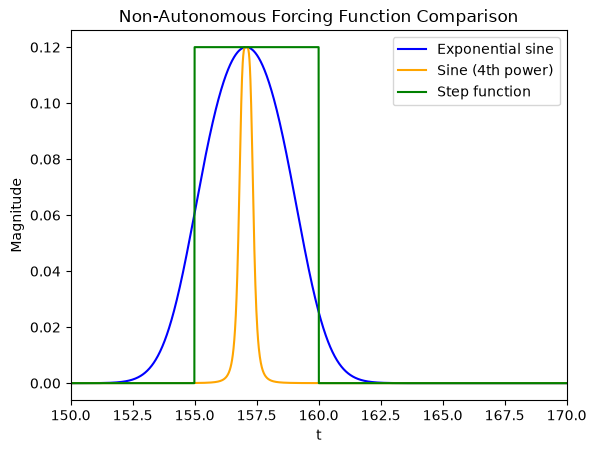

In [4]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.arange(0,500,0.01)
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.xlim(150,170)
plt.xlabel('t')
plt.ylabel('Magnitude')
plt.title('Non-Autonomous Forcing Function Comparison')
plt.legend()

# 1.) VF-FHN
Now, let's try fitting the above with some non-autonomous terms included.

In [5]:
# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_7 = np.arange(0,4000,dt)
x_0_vf_7 = np.array([0,0])

In [6]:
fhn_vf_4_part = functools.partial(fhn_vf_4, alpha = 0.2, beta = 1.1, eps = 0.005, mu = 1.0)

t_vf_4 = np.arange(0,4000,dt)
x_0_vf_4 = np.array([0,0.11])

# (Uncomment to determine the optimal period for 4-parameter version of VF-FHN)

# # Compare how different stimulus periods affect the FHN VF-a waveforms.
# for i in range(0,4):
#     cur_period = 170. + 5*i
#     non_aut_func = functools.partial(logical_non_aut, period=cur_period, dur=5.0, mag=0.12)
#     cur_states_fhn = odeint(fhn_vf_4_part, x_0_vf_4, t_vf_4, args=(non_aut_func,), hmax=0.1)

#     cur_df_states_fhn = pd.DataFrame(cur_states_fhn, columns=['u','v'])
#     cur_u_fhn = cur_df_states_fhn['u'].tolist()

#     plt.plot(t_vf_4, cur_u_fhn)
#     plt.title(f"VF-FHN with Stimulus Period {cur_period:.0f} Time Units")
#     plt.gcf().set_size_inches(10, 2.5) # Change plot size so we quickly see differences in waveforms
#     plt.show()

In [7]:
fhn_vf_7_part = functools.partial(fhn_vf_7, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0)

# (Uncomment to determine the optimal period)

# # Compare how different stimulus periods affect the FHN VF-b waveforms.
# for i in range(0,20):
#     cur_period = 350. + i
#     non_aut_func = functools.partial(logical_non_aut, period=cur_period, dur=5.0, mag=0.12)
#     cur_states_fhn = odeint(fhn_vf_7_part, x_0_vf_7, t_vf_7, args=(non_aut_func,), hmax=0.1)

#     cur_df_states_fhn = pd.DataFrame(cur_states_fhn, columns=['u','v'])
#     cur_u_fhn = cur_df_states_fhn['u'].tolist()

#     plt.plot(t_vf_7, cur_u_fhn)
#     plt.title(f"VF-FHN with Stimulus Period {cur_period:.0f} Time Units")
#     plt.gcf().set_size_inches(10, 2.5) # Change plot size so we quickly see differences in waveforms
#     plt.show()

Based on the plots above, T = 361 time units gives the best result, with the VF-b variant of FHN seeming very sensitive to the correct stimulus period. Any variation from this value results in alternans and/or the stimulus occurring in the middle of an AP. Here is a compilation of the optimal period for various sets of parameters:

* alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0 — T = 361
* alpha = 0.2, beta = 1.03, gamma = 0.31, delta = 0.0, eps = 0.003, theta = -0.05, mu = 1.1 — T = 765

In [8]:
# Generate the data using our non-autonomous term. Note that the period is very sensitive per the above experiment, so we must be careful in our selection of its value.
non_aut_func_vf_7 = functools.partial(logical_non_aut, period=361, dur=5.0, mag=0.12)

states_vf_7 = odeint(fhn_vf_7_part, x_0_vf_7, t_vf_7, args=(non_aut_func_vf_7,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> non_aut_func_vf_7

In [9]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up
# TODO How to remove these terms?
opt_vf_7 = ps.STLSQ(threshold=0.1, normalize_columns=True)
model_vf_7 = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_7)
model_vf_7.fit(states_vf_7, t=t_vf_7, feature_names=["u", "v"])
model_vf_7.print(precision=5)

(u)' =  0.00535 1 +  0.61530 u + -0.01588 v + -0.51201 u^2 + -4.69326 u v + -0.81204 v^2 + -0.10885 u^3 +  3.80815 u^2 v +  4.49714 u v^2 +  3.31970 v^3
(v)' = -0.00145 1 +  0.00705 u + -0.00500 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Based on the result above, it seems we can identify $\dot{v}$, but not $\dot{u}$, when a stimulus is applied and not accounted for by SINDy.  This is to be expected since the stimulus term is only added to the $\dot{u}$ equation.

Number of SINDy terms for u', v': (10, 3)
Number of exact terms for u', v': (4, 4)

SINDy coefficients:
(u)' =  0.00535 1 +  0.61530 u + -0.01588 v + -0.51201 u^2 + -4.69326 u v + -0.81204 v^2 + -0.10885 u^3 +  3.80815 u^2 v +  4.49714 u v^2 +  3.31970 v^3
(v)' = -0.00145 1 +  0.00705 u + -0.00500 u^2

Exact coefficients:
u' = -0.22 u + 0.42 u^2 + -1.0 uv + -0.2 u^3 + 0.0 v^3
v' = 0.0515 1 + 0.3193 u + -0.00309 v + -1.03 u^2 + 0.0 v^3


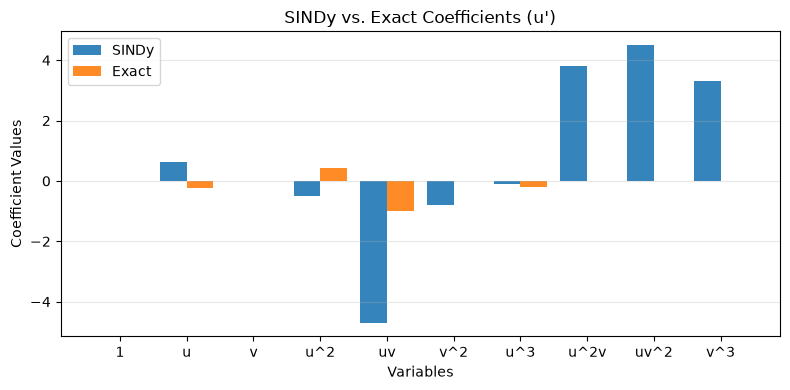

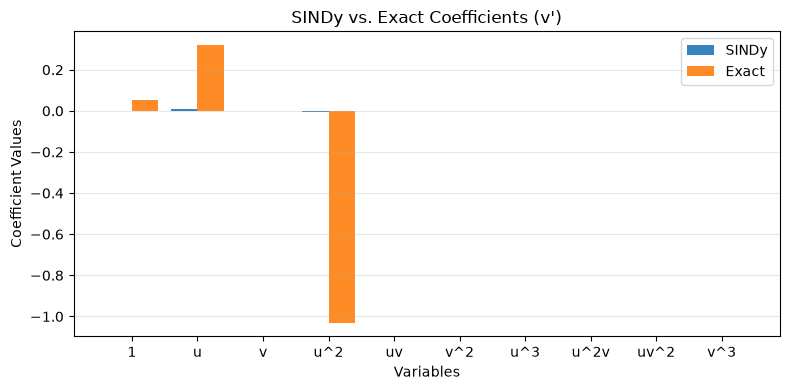

In [10]:
# Order of coefficients: 1, u, v, u^2, uv, v^2, u^3, u^2v, uv^2, v^3
variables = ["1", "u", "v", "u^2", "uv", "v^2", "u^3", "u^2v", "uv^2", "v^3"]
coef_sindy = model_vf_7.coefficients()
coef_exact = np.array([[0, -0.22, 0, 0.42, -1.0, 0, -0.2, 0, 0, 0],
                       [0.0515, 0.3193, -0.00309, -1.03, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
x = np.arange(len(coef_sindy[0]))

# Compare number of terms in the SINDy model to the exact coefficients.
precision = 5
tol = 10**(-precision)
print(f"Number of SINDy terms for u\', v\': ({np.sum(np.abs(coef_sindy[0]) > tol)}, {np.sum(np.abs(coef_sindy[1]) > tol)})")
print(f"Number of exact terms for u\', v\': ({np.sum(np.abs(coef_exact[0]) > tol)}, {np.sum(np.abs(coef_exact[1]) > tol)})")

# Compare the SINDy and exact coefficients.
print("\nSINDy coefficients:")
model_vf_7.print(precision=precision)
print("\nExact coefficients:")
for i in range(len(coef_exact)):
    eqn = ""
    eqn += ("u\' = " if i == 0 else "v\' = ")
    for j in range(len(coef_exact[0])):
        if (np.abs(coef_exact[i][j]) > tol) and (j < len(coef_exact[0]) - 1):  # Print only nonzero coefficients.
            eqn += f"{coef_exact[i][j]} {variables[j]} + "
        elif (j == len(coef_exact[0]) - 1):  # Handle the last term separately.
            eqn += f"{coef_exact[i][j]} {variables[j]}"
    print(eqn)


# Use bar chart to compare the SINDy and exact coefficient values (for u').
width = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, coef_sindy[0], width=width, alpha=0.9, label='SINDy')
plt.bar(x + width/2, coef_exact[0], width=width, alpha=0.9, label='Exact')

plt.title('SINDy vs. Exact Coefficients (u\')')
plt.ylabel('Coefficient Values')
plt.xlabel('Variables')
plt.xticks(x, variables)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)


# Use bar chart to compare the SINDy and exact coefficient values (for v').
width = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, coef_sindy[1], width=width, alpha=0.9, label='SINDy')
plt.bar(x + width/2, coef_exact[1], width=width, alpha=0.9, label='Exact')

plt.title('SINDy vs. Exact Coefficients (v\')')
plt.ylabel('Coefficient Values')
plt.xlabel('Variables')
plt.xticks(x, variables)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

Text(0.5, 1.0, 'Values of u vs. v')

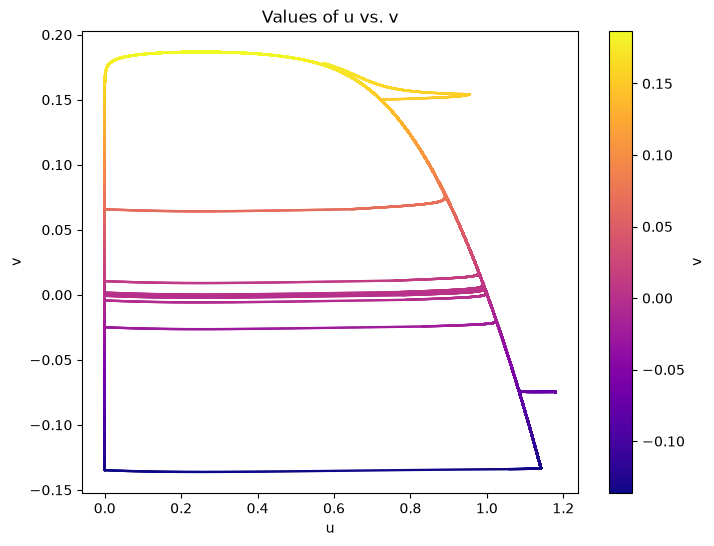

In [11]:
# Plot results - u vs. v
df_states_vf_7 = pd.DataFrame(states_vf_7, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_7['u'], 
    df_states_vf_7['v'], 
    c=df_states_vf_7['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0011988115034597003, 0.002395261989364361, 0.003589390000766398, 0.004781233289104066, 0.0059708220035531775, 0.00715820131495333, 0.008343415251760687, 0.009526505707204936, 0.01070750320662103]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


Text(0.5, 1.0, 'Voltage vs. Time (VF-FHN)')

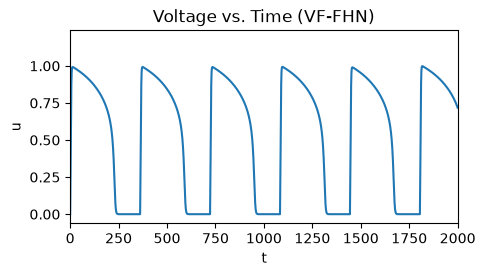

In [12]:
# Plot results - u vs. t
u_vf_7 = df_states_vf_7['u'].tolist()
print(u_vf_7[0:10])
print(t_vf_7[0:10])

plt.figure(figsize=(5, 2.5))
plt.plot(t_vf_7,u_vf_7)
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (VF-FHN)')

# 2.) FHN
Now, fit standard FHN model with non-autonomous terms.

In [13]:
# Standard FHN parameters
t_fhn = np.arange(0,2000,dt)
x_0_fhn = np.array([0,0])
states_fhn = odeint(fhn, x_0_fhn, t_fhn, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [14]:
# Run SINDy on FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_fhn = ps.STLSQ(threshold=0.1, normalize_columns=True)
model_fhn = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn, feature_names=["u", "v"])
model_fhn.print(precision=5)

(u)' =  0.03218 1 +  0.54900 u +  0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 +  5.83089 u^2 v +  21.42263 u v^2 +  61.47220 v^3
(v)' =  0.00500 u + -0.01000 v


In [15]:
# TODO Why does using standard function library (e.g., removing feature_library argument) result in fewer extraneous terms here?
model_fhn = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn, feature_names=["u", "v"])
model_fhn.print(precision=5)

(u)' =  0.03218 1 +  0.54900 u +  0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 +  5.83089 u^2 v +  21.42263 u v^2 +  61.47220 v^3
(v)' =  0.00500 u + -0.01000 v


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 uv - 1 u^3 \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1uv - 1 u^3 \\
    \dot{v} &= - 0.01 + 0.005 u - 0.01v \\
\end{align}

Even with the simpler FHN model, we get the same result as with VF-FHN—the stimulus term must be taken into account in order for the $\dot{u}$ equation to be correctly identified.

Text(0.5, 1.0, 'Values of u vs. v')

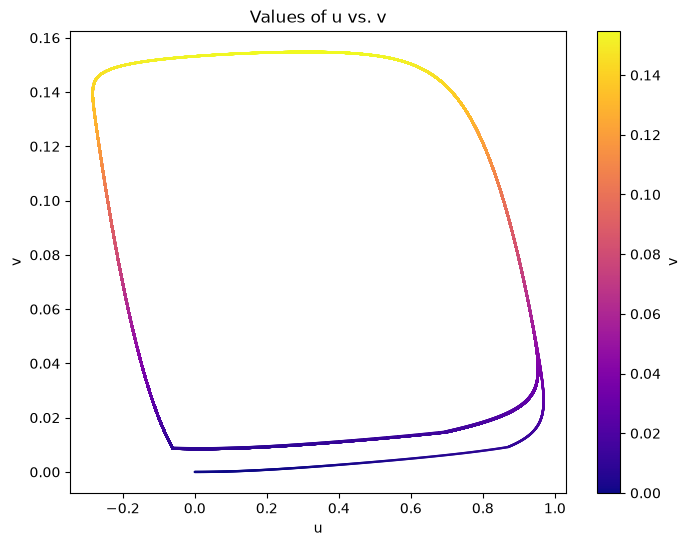

In [16]:
# Plot results - u vs. v
df_states_fhn = pd.DataFrame(states_fhn, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_fhn['u'], 
    df_states_fhn['v'], 
    c=df_states_fhn['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

### Cardiac FHN vs. normal FHN—Hyperpolarization Comparison

In [17]:
# Cardiac-corrected FHN ICs and time range
t_fhn_c = np.arange(0,4000,dt)
x_0_fhn_c = np.array([0,0.11])

# Generate the data using our non-autonomous term. Note that the period is very sensitive per the above experiment, so we must be careful in our selection of its value.
non_aut_func_fhn_c = functools.partial(logical_non_aut, period=361, dur=5.0, mag=0.12)
fhn_c_part = functools.partial(fhn_c, alpha = 0.1, beta = 0.5, gamma = 1, delta = 0.0, eps = 0.01)

states_fhn_c = odeint(fhn_c_part, x_0_fhn_c, t_fhn_c, args=(non_aut_func_fhn_c,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> non_aut_func_vf_7
df_states_fhn_c = pd.DataFrame(states_fhn_c, columns=['u','v'])
u_fhn_c = df_states_fhn_c['u'].tolist()

[0.0, 0.0011994098198587781, 0.002397651144048946, 0.0035947547308883116, 0.0047907558187071835, 0.005985674083706682, 0.007179547898377901, 0.008372413867041097, 0.009564306477421403, 0.010755250757803373]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


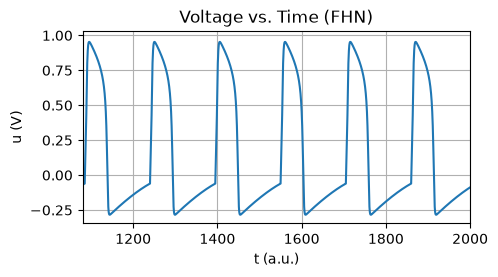

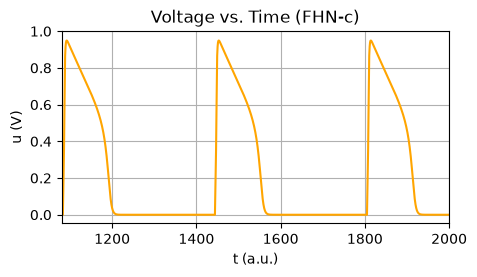

In [18]:
# Plot FHN u vs. t
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

plt.figure(figsize=(5, 2.5))    # , dpi=600
plt.plot(t_fhn,u_fhn)
plt.xlim(1080, 2000)
plt.xlabel('t (a.u.)')
plt.ylabel('u (V)')
plt.title('Voltage vs. Time (FHN)')
plt.grid()

# Plot FHN-c - u vs. t
plt.figure(figsize=(5, 2.5))    # , dpi=600
plt.plot(t_fhn_c,u_fhn_c, color='orange')
plt.xlim(1080, 2000)
plt.xlabel('t (a.u.)')
plt.ylabel('u (V)')
plt.title('Voltage vs. Time (FHN-c)')
plt.grid()
plt.show()

# Experimental Section
Includes subtraction of logical_non_aut before passing to SINDy, FFT of voltage response, etc.

[0.0, 0.0011994098198587781, 0.002397651144048946, 0.0035947547308883116, 0.0047907558187071835, 0.005985674083706682, 0.007179547898377901, 0.008372413867041097, 0.009564306477421403, 0.010755250757803373]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


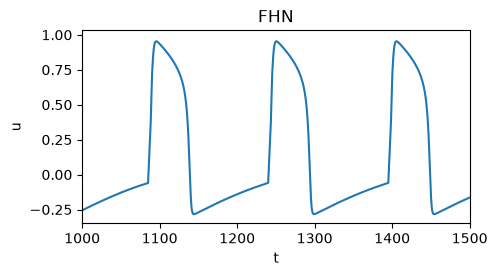

Text(0.5, 1.0, 'FHN (Non-Autonomous Term Subtracted)')

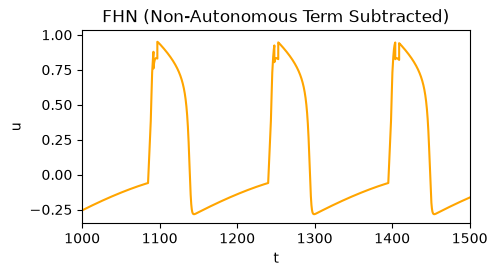

In [19]:
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

# Plot result - u vs. t
plt.figure(figsize=(5, 2.5))
plt.plot(t_fhn,u_fhn)
plt.xlim(1000, 1500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('FHN')
plt.show()

# Now subtract the non-autonomous term to try to ID the original FHN dynamics. Because of the nonlinear effects, the spike at the peak will be slightly off, making this method not work particularly well.
plt.figure(figsize=(5, 2.5))
plt.plot(t_fhn,u_fhn - logical_non_aut(t_fhn, period=156, dur=5, mag=0.12), color='orange')
plt.xlim(1000, 1500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('FHN (Non-Autonomous Term Subtracted)')

Text(0.5, 1.0, 'FFT of FHN u Values')

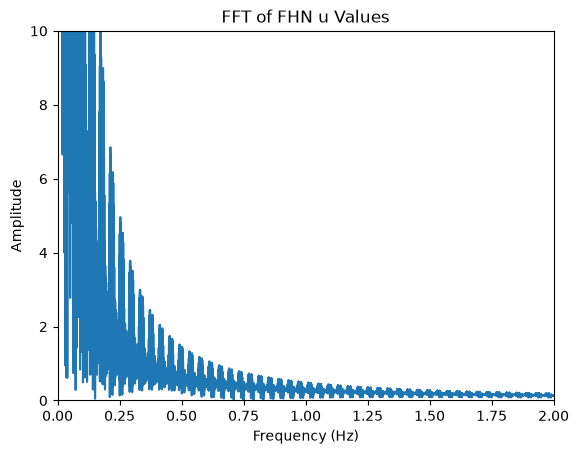

In [20]:
# Test analyzing time series in frequency space to see if we can tease out the non-autonomous signal.
# TODO Figure out what whether scipy.fft is being used incorrectly
w_fhn = fft.fft(u_fhn)
w_fhn = np.abs(w_fhn[0:len(w_fhn)//2]) # Take the first half of the FFT result, making sure to make all values real.
w = np.arange(0, 10, dt / 100.)
plt.plot(w, w_fhn)
plt.ylim(0, 10)
plt.xlim(0, 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT of FHN u Values')

# 3.) Using GeneralizedLibrary to ID Non-Autonomous Terms
We can use pySINDy's `GeneralizedLibrary` class to combine multiple `CustomLibrary` instances while also restricting which functions can apply to which equations using the argument inputs_per_library. This is useful since we know that the time-dependent term will only appear in the $u$ (voltage) equation.

In [21]:
# TODO Calling w/ functools.partial() results in no .__code__ on pySINDy call, so have to define functions explicitly; would like to refactor in better way.
# Define battery of similar non-autonomous terms on which to test SINDy with the GeneralizedLibrary implementation above.
# Recall - 0.12 approximately optimal stimulus (for period 0.08 * 1.5 --> 0.12).
func_test = lambda t: (np.sin(0.01*t))**2
def func_log(t):
    return logical_non_aut(t, period=155.0, dur=5.0, mag=0.12)
def func_smooth(t):
    return smooth_non_aut(t, mag=0.12)
def func_smooth_old(t):
    return smooth_non_aut_old(t, mag=0.12)
funcs = [func_test, func_log, func_smooth, func_smooth_old]

### a.) FHN Test

----------Fitting with function: <lambda>----------
Number of SINDy terms for u', v': (5, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 7.01406e-07

SINDy coefficients:
(u)' = -0.10000 u + -1.00000 v +  1.10000 u^2 + -1.00000 u^3 +  1.00000 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + -1.00000 v + 1.10000 u^2 + -1.00000 u^3 + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and true values: 1.16741e-07



----------Fitting with function: func_log----------
Number of SINDy terms for u', v': (9, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 1.85417e-02

SINDy coefficients:
(u)' = -0.09943 u + -1.00091 v +  1.09886 u^2 +  0.04907 v^2 + -0.99949 u^3 + -0.27693 v^3 + -0.00176 u*v +  0.00007 1 +  0.99721 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + -1.00000 v + 1.10000 u^2 + -1.00000 u^

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


Number of SINDy terms for u', v': (8, 0)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 4.60162e+00

SINDy coefficients:
(u)' = -0.09999 u + -1.00030 v +  1.10078 u^2 + -0.18679 v^2 + -1.00469 u^3 +  82.61012 v^3 + -0.01124 u*v +  0.99983 f_td(t)
(v)' =  0.00000
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + -1.00000 v + 1.10000 u^2 + -1.00000 u^3 + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and true values: 8.67013e-03



----------Fitting with function: func_smooth_old----------
Number of SINDy terms for u', v': (7, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 3.49325e-05

SINDy coefficients:
(u)' = -0.10000 u + -1.00000 v +  1.10000 u^2 +  0.00010 v^2 + -1.00000 u^3 + -0.00051 v^3 +  1.00000 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + -1.00000 v + 1.10000 u^2 + -1.00000 u^3 + 1.00000 f_td
v' = 0.00500 u + -0.01000

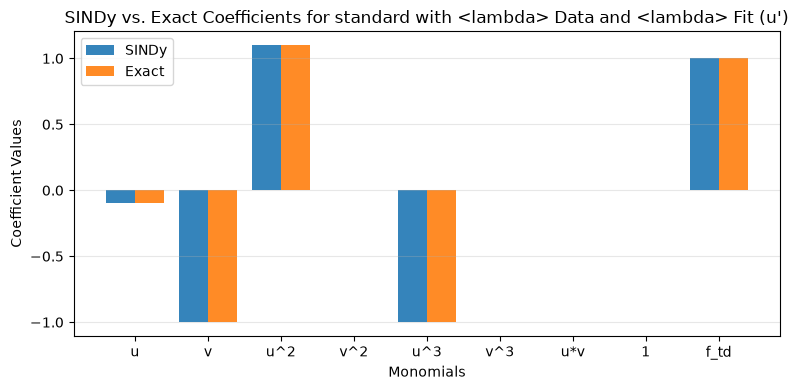

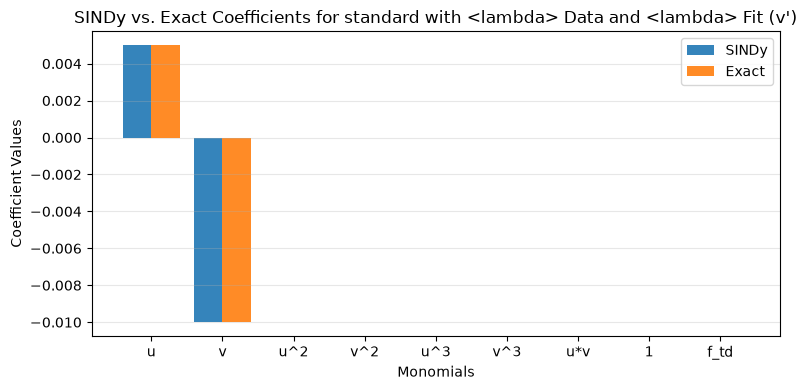

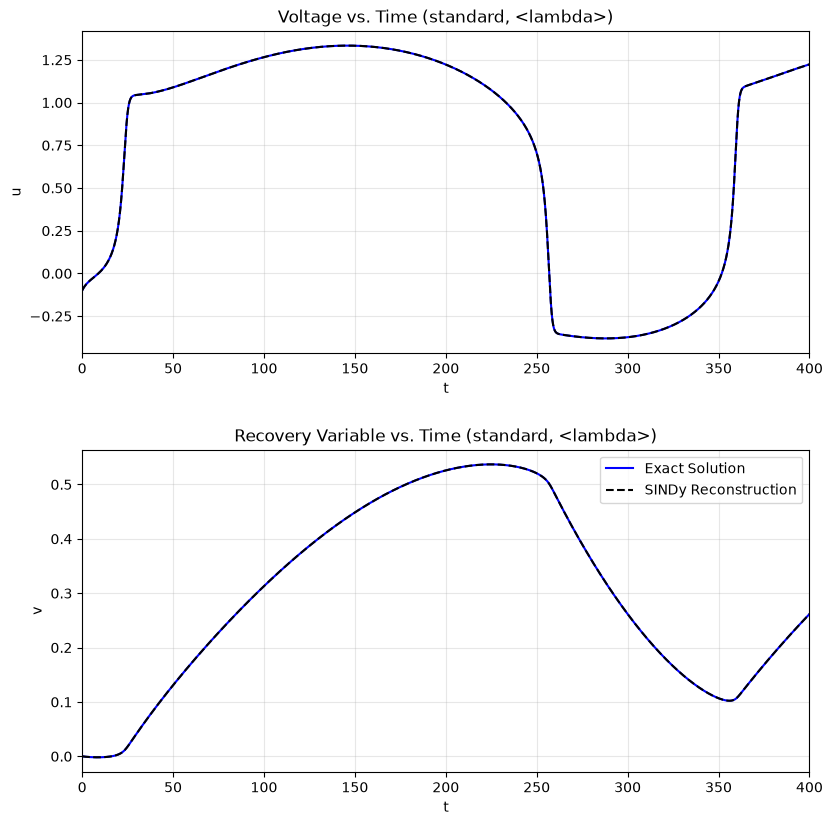

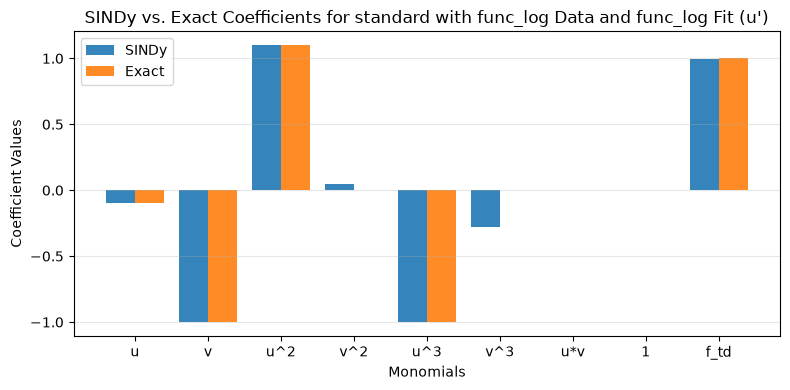

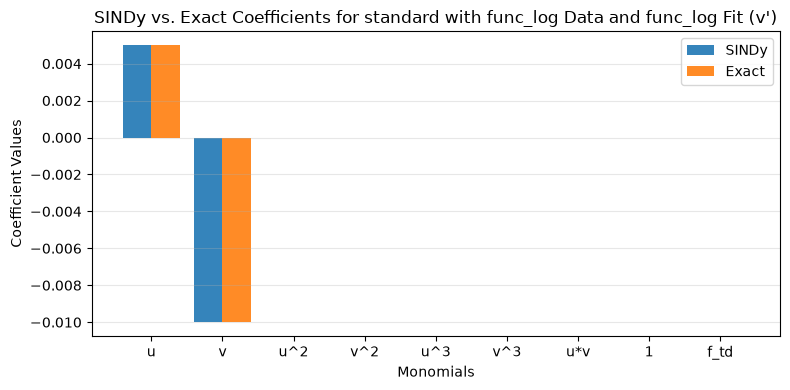

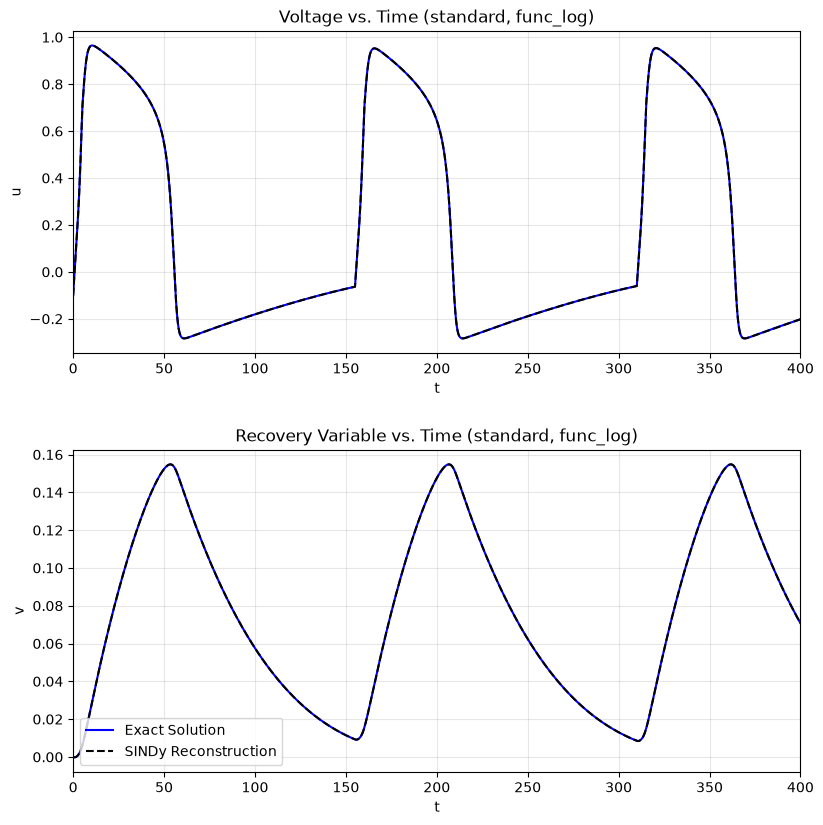

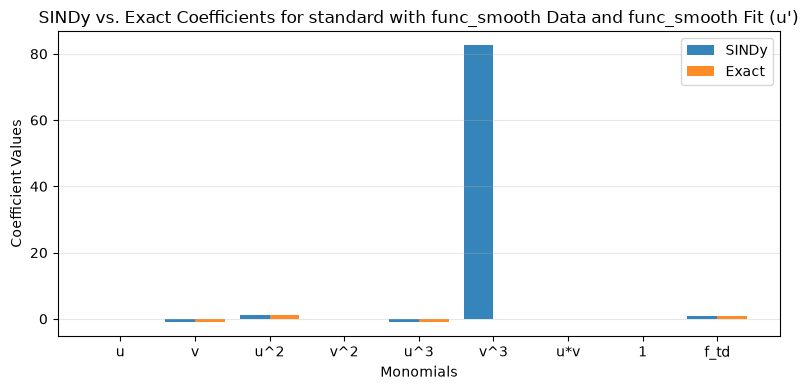

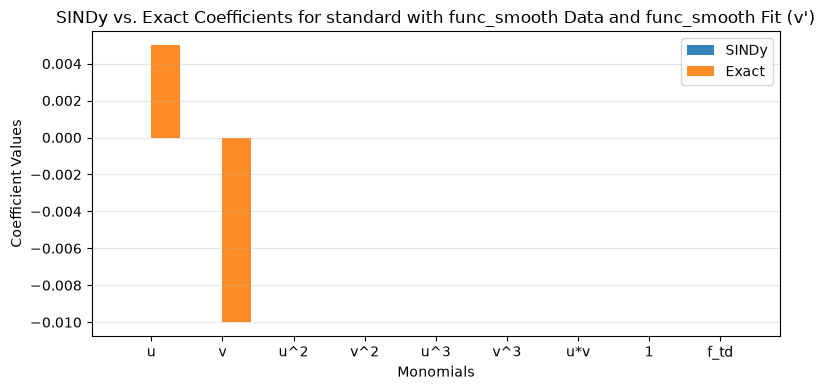

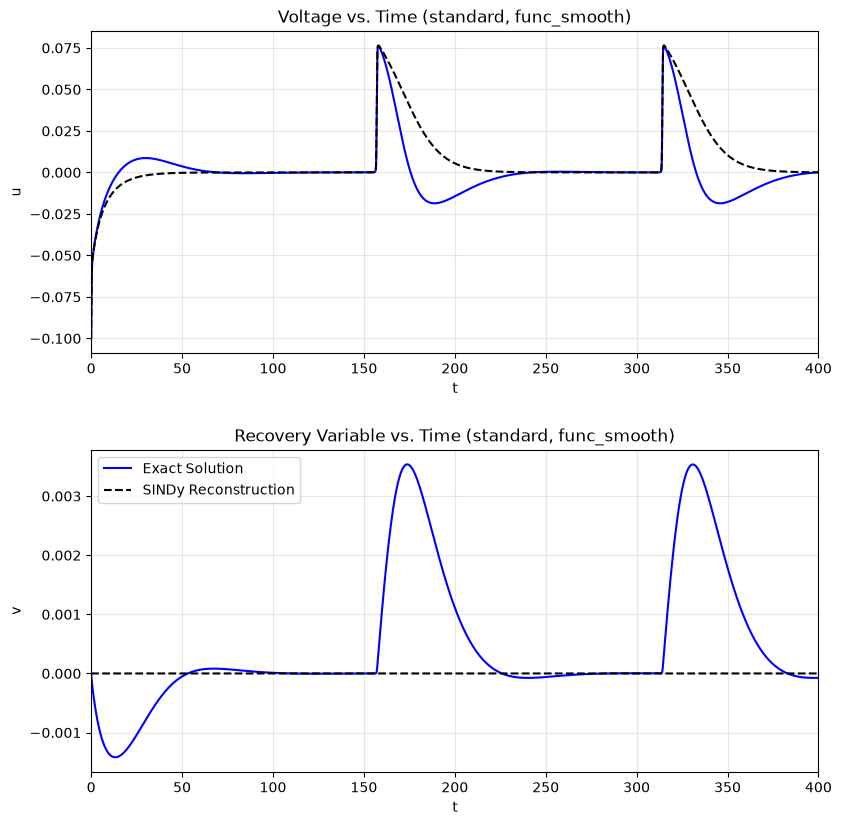

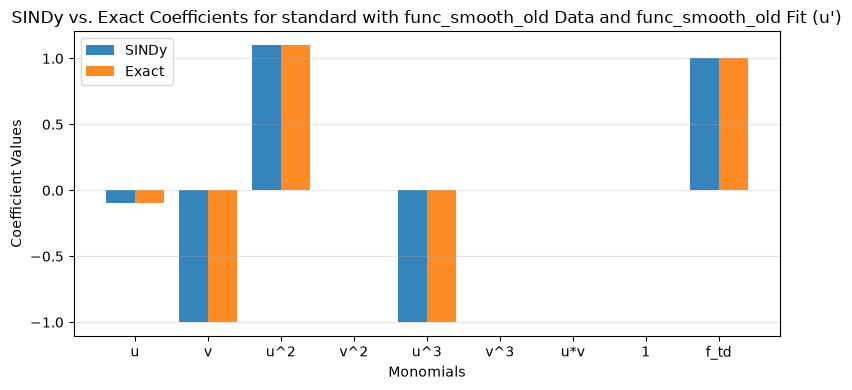

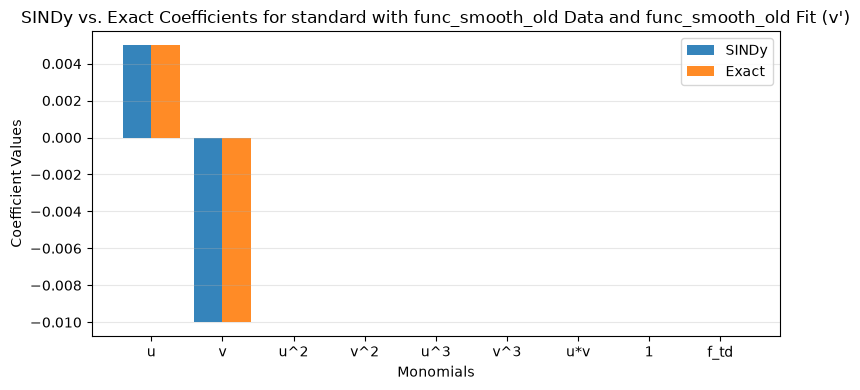

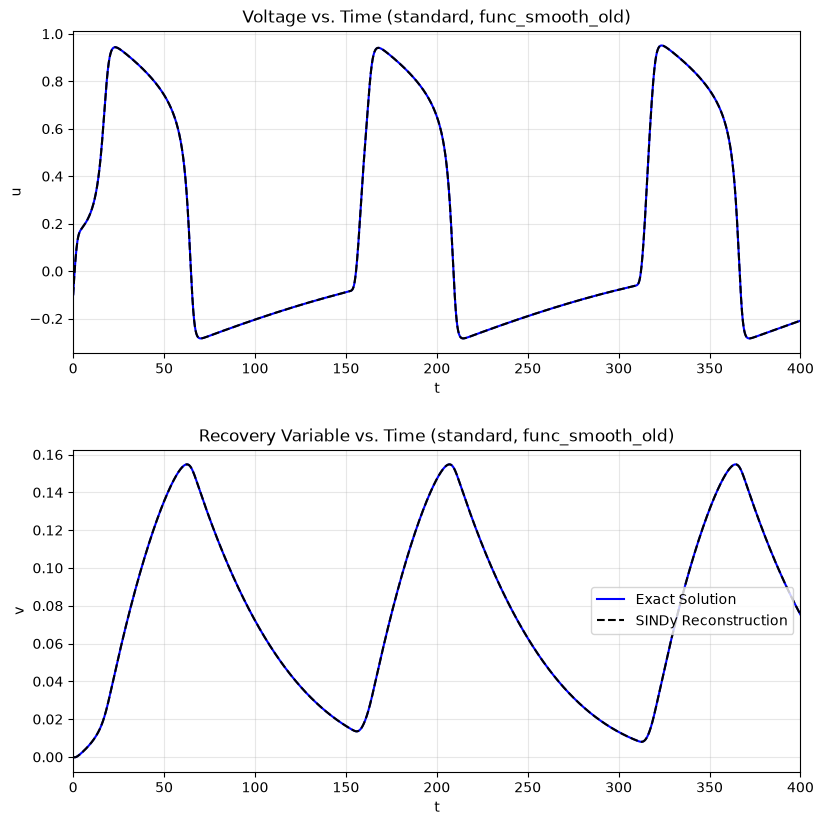

In [22]:
a_models = []

# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"----------Fitting with function: {func.__name__}----------")
    cur_gen_library_a = GenLibraryFit(func, func, fhn_variant="standard", color="blue")
    a_models.append(cur_gen_library_a.fit())
    print('\n\n')

Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 u^3 - 1 v + f_{td}(t) \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

##### Different Fit and Data Stimuli

----------Fitting logical_non_aut data with smooth_non_aut fit----------
Number of SINDy terms for u', v': (9, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 8.04770e+00

SINDy coefficients:
(u)' =  0.16420 u + -1.88209 v +  0.87470 u^2 +  22.80391 v^2 + -1.06029 u^3 + -118.72661 v^3 + -0.95283 u*v +  0.03987 1 +  0.09653 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + -1.00000 v + 1.10000 u^2 + -1.00000 u^3 + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and true values: 4.99002e-01





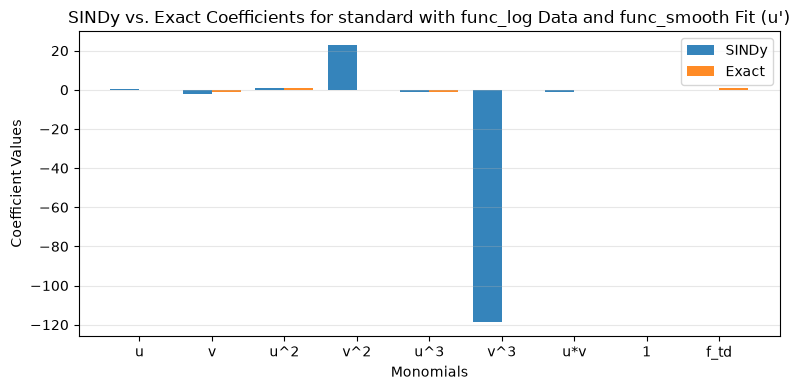

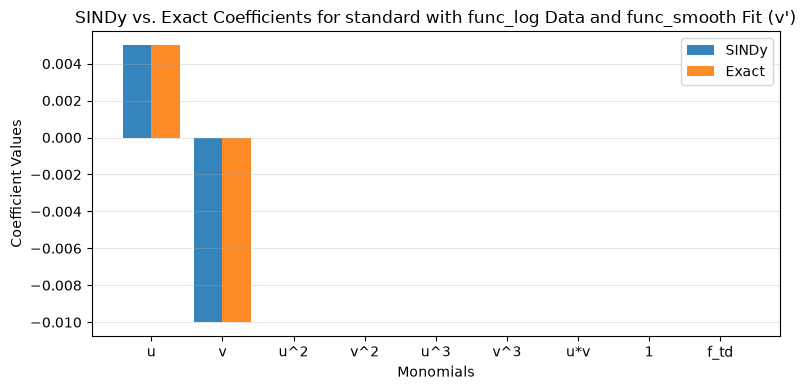

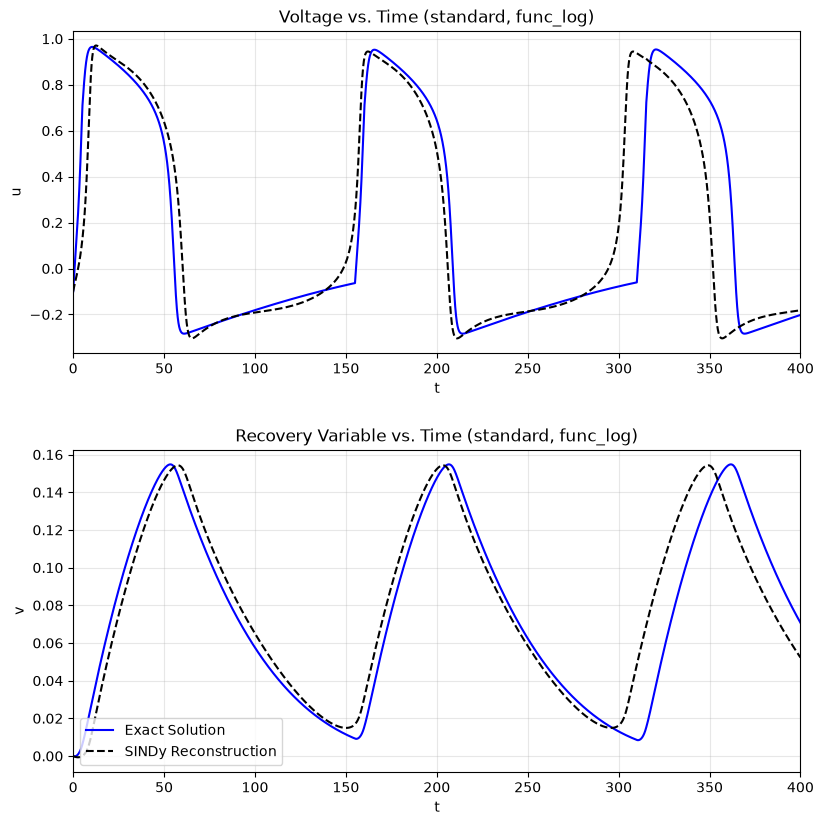

In [23]:
# TODO Can't correctly ID w/ similar-looking non-autonomous functions; the magnitude of the effect of small differences in stimulus currents is a clear limitation.
# Test fit with different data and fitting non-autonomous terms.
print(f"----------Fitting logical_non_aut data with smooth_non_aut fit----------")
cur_gen_library_a = GenLibraryFit(func_log, func_smooth, fhn_variant="standard", color="blue")
cur_gen_library_a.fit()
print('\n\n')

### b.) FHN-c Test

----------Fitting with function: <lambda>----------
Number of SINDy terms for u', v': (8, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 3.80894e-01

SINDy coefficients:
(u)' =  0.08046 u +  0.21304 v + -1.41165 v^2 + -0.12375 u^3 +  1.38515 v^3 + -0.09379 u*v +  0.03033 1 +  0.24700 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and true values: 4.37509e-02



----------Fitting with function: func_log----------
Number of SINDy terms for u', v': (9, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 2.44957e-02

SINDy coefficients:
(u)' = -0.09746 u + -0.01030 v +  1.09376 u^2 +  0.10282 v^2 + -0.99640 u^3 + -0.31033 v^3 + -0.99909 u*v +  0.00030 1 +  0.99610 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.100

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(
c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


Number of SINDy terms for u', v': (4, 0)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 8.93054e-02

SINDy coefficients:
(u)' = -0.10330 u +  1.05312 u^2 + -0.45844 u*v +  1.00076 f_td(t)
(v)' =  0.00000
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and true values: 4.18285e-04



----------Fitting with function: func_smooth_old----------
Number of SINDy terms for u', v': (7, 2)
Number of exact terms for u', v': (5, 2)
Mean Absolute Error of coefficients: 2.83568e-06

SINDy coefficients:
(u)' = -0.10000 u +  1.10000 u^2 + -0.00001 v^2 + -1.00000 u^3 +  0.00004 v^3 + -1.00000 u*v +  1.00000 f_td(t)
(v)' =  0.00500 u + -0.01000 v
(t)' =  1.00000 1

Exact coefficients:
u' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00500 u + -0.01000 v


Mean Absolute Error between reconstruction and t

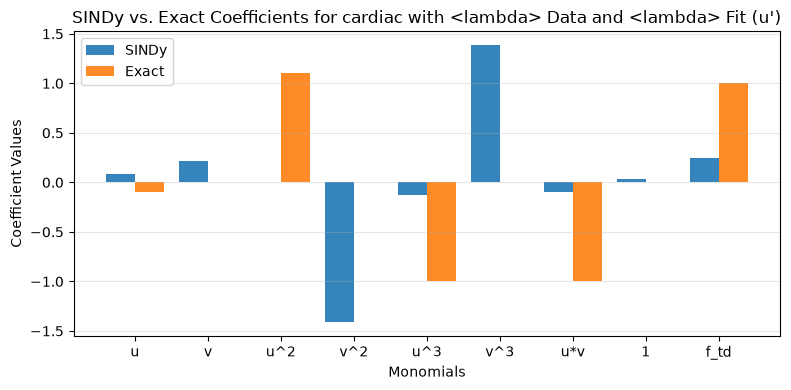

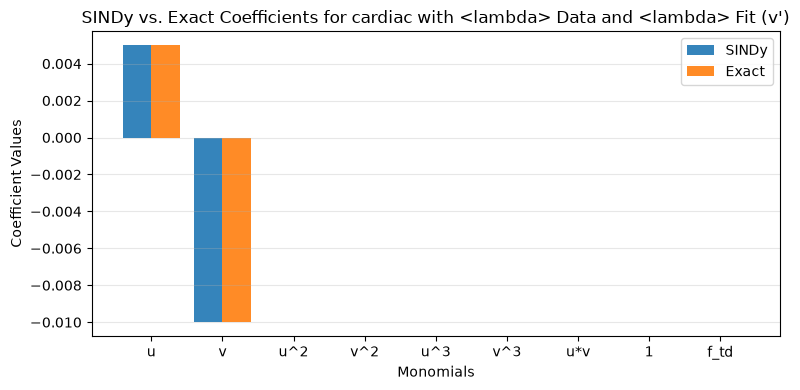

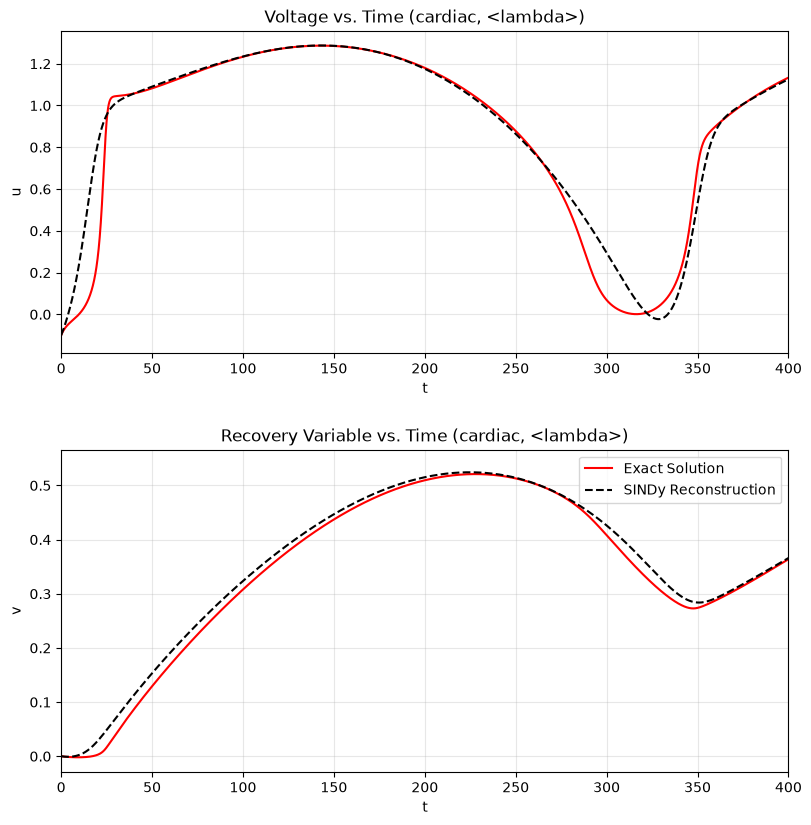

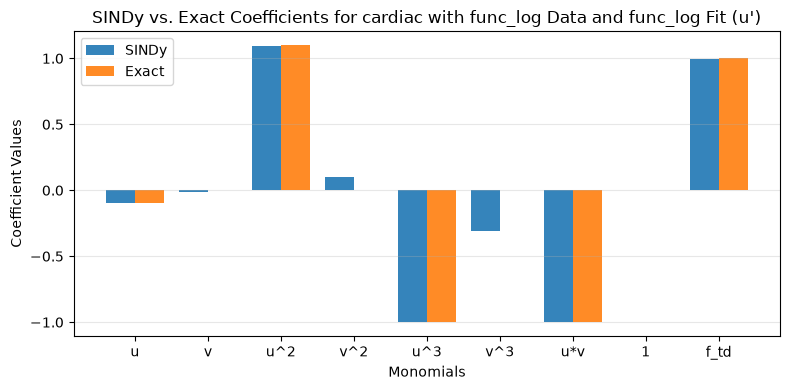

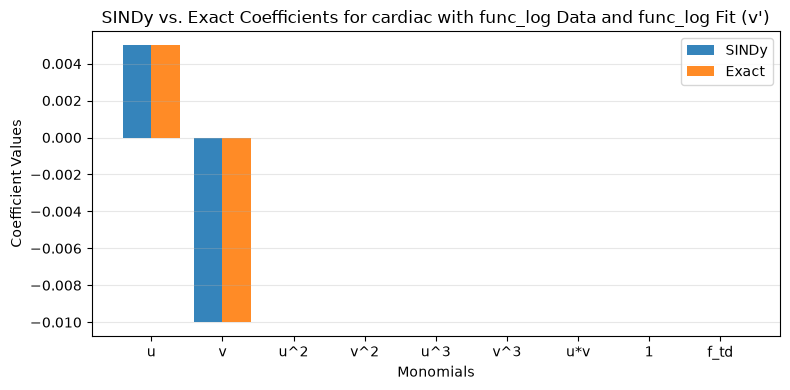

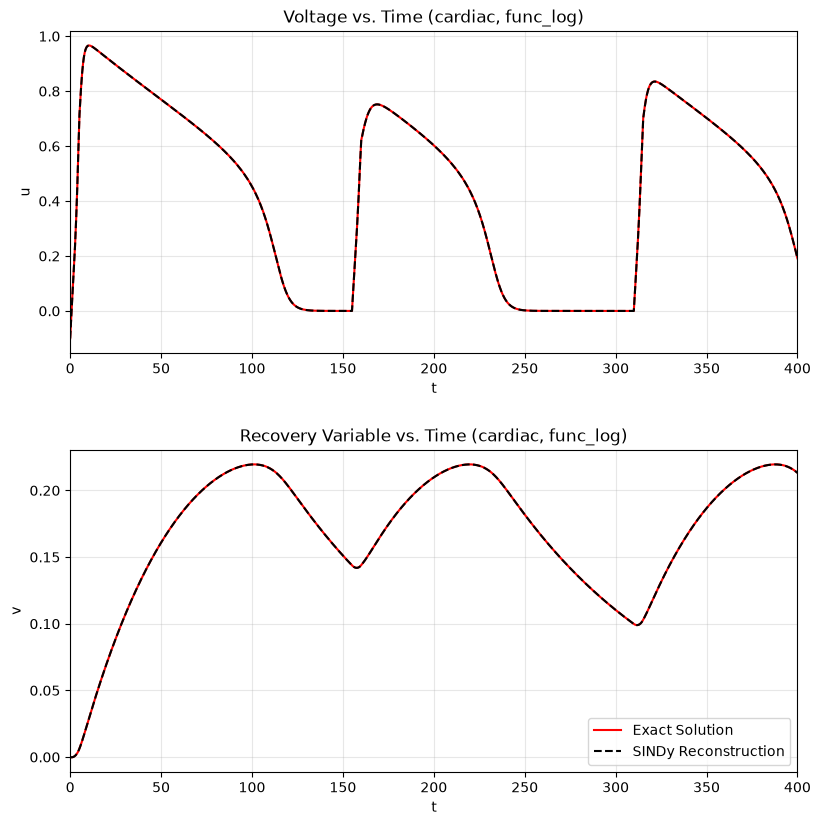

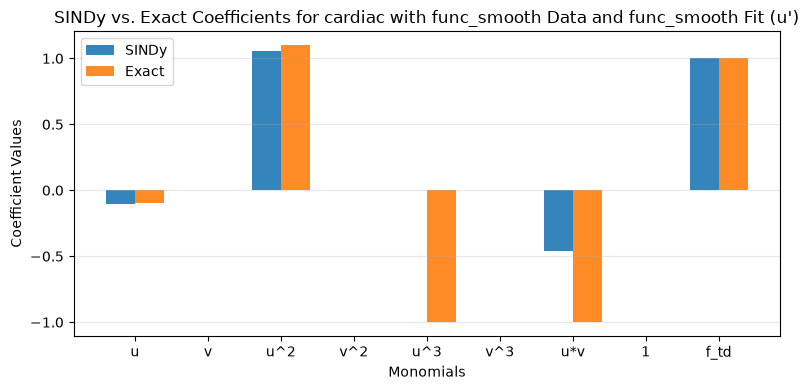

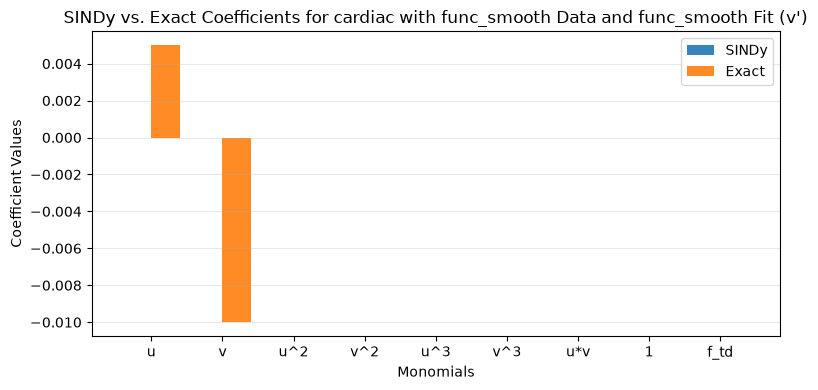

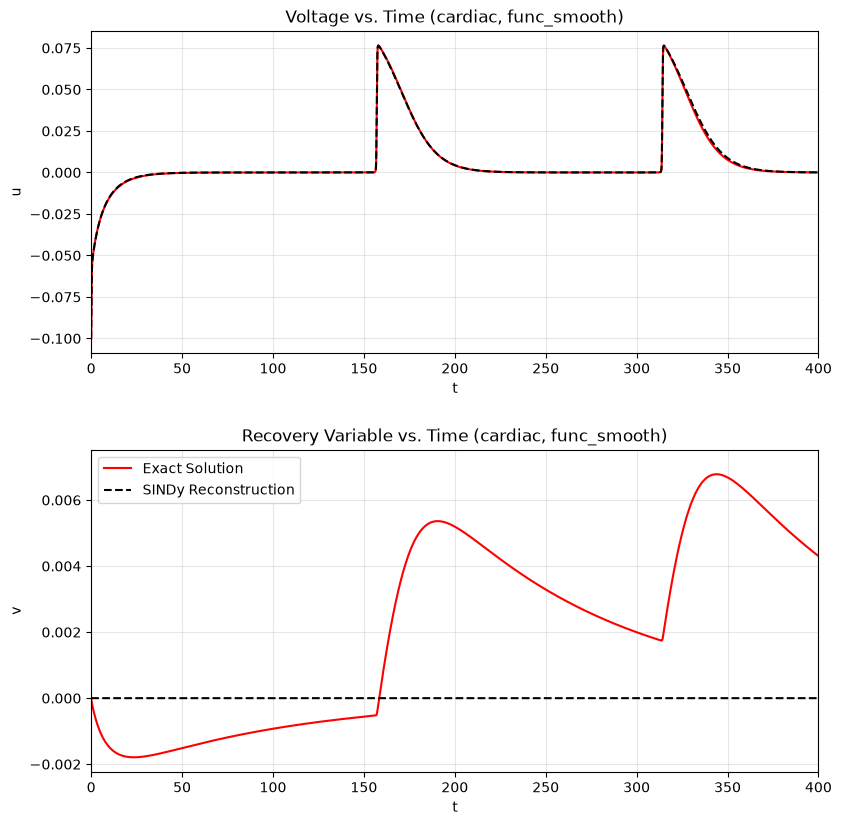

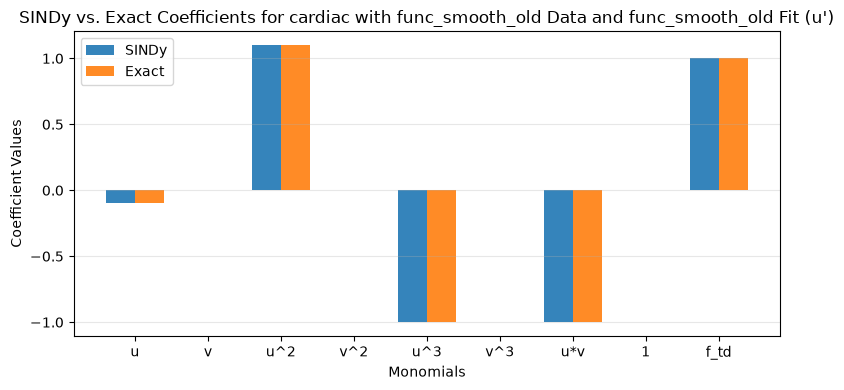

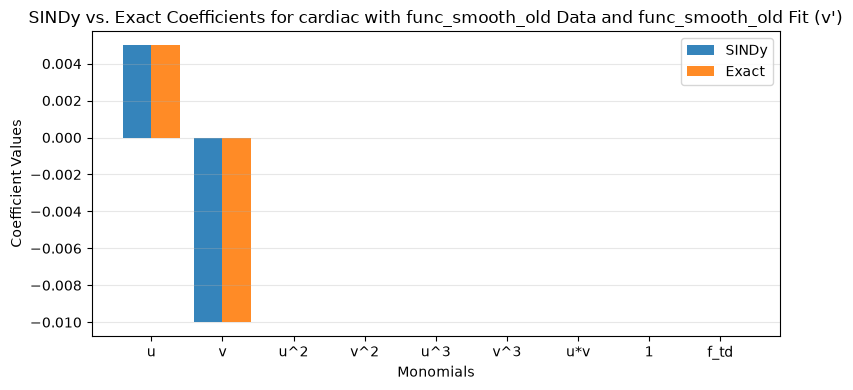

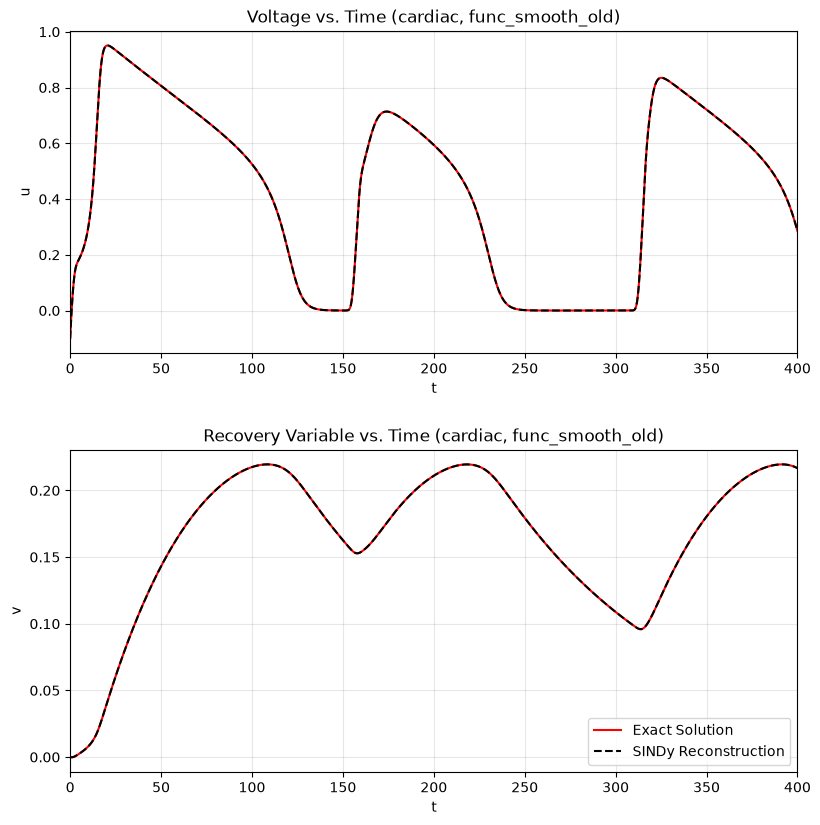

In [36]:
b_models = []

# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"----------Fitting with function: {func.__name__}----------")
    cur_gen_library_b = GenLibraryFit(func, func, fhn_variant="cardiac", color="red")
    b_models.append(cur_gen_library_b.fit())
    print('\n\n')

Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 u^3 - 1 u v + f_{td}(t) \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

### c.) VF-FHN (a) Test
Test SINDy ID on the 4-parameter VF-FHN model (also called VF-4).  Note that this model's parameters put it in an alternans regime since it is the easiest to tune for such behavior.

----------Fitting with function: func_log_vf_4----------
Number of SINDy terms for u', v': (9, 4)
Number of exact terms for u', v': (5, 3)
Mean Absolute Error of coefficients: 4.40620e-01

SINDy coefficients:
(u)' = -0.19656 u + -0.31136 v +  1.18956 u^2 +  2.24040 v^2 + -0.99228 u^3 + -5.31157 v^3 + -0.99973 u*v +  0.01425 1 +  0.99595 f_td(t)
(v)' = -0.00027 u + -0.00373 v +  0.01549 u*v + -0.00012 1
(t)' =  1.00000 1

Exact coefficients:
u' = -0.20000 u + 1.20000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00550 u + -0.00500 v + -0.00500 u^2


Mean Absolute Error between reconstruction and true values: 8.54844e-02





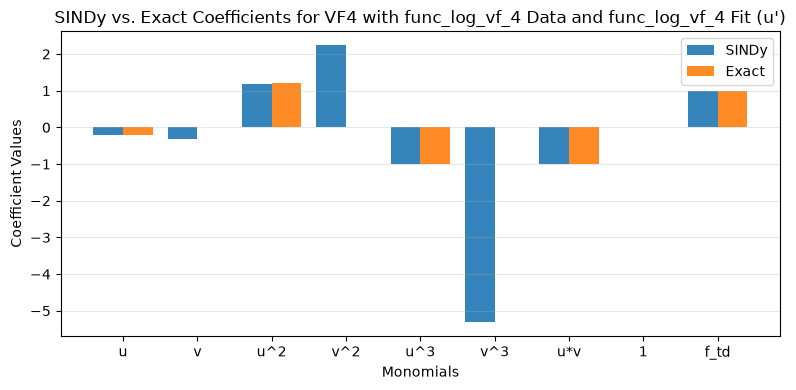

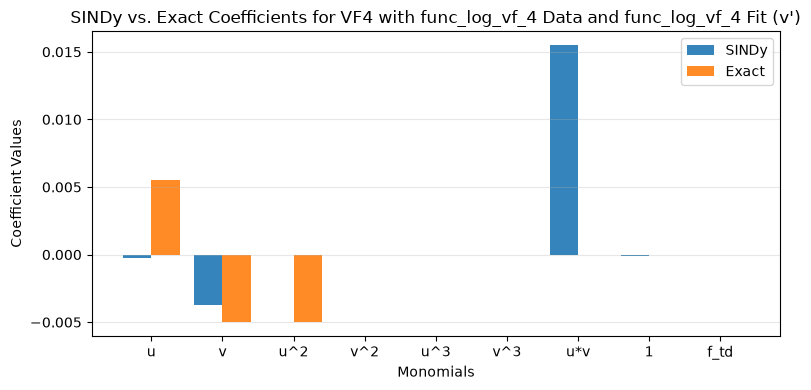

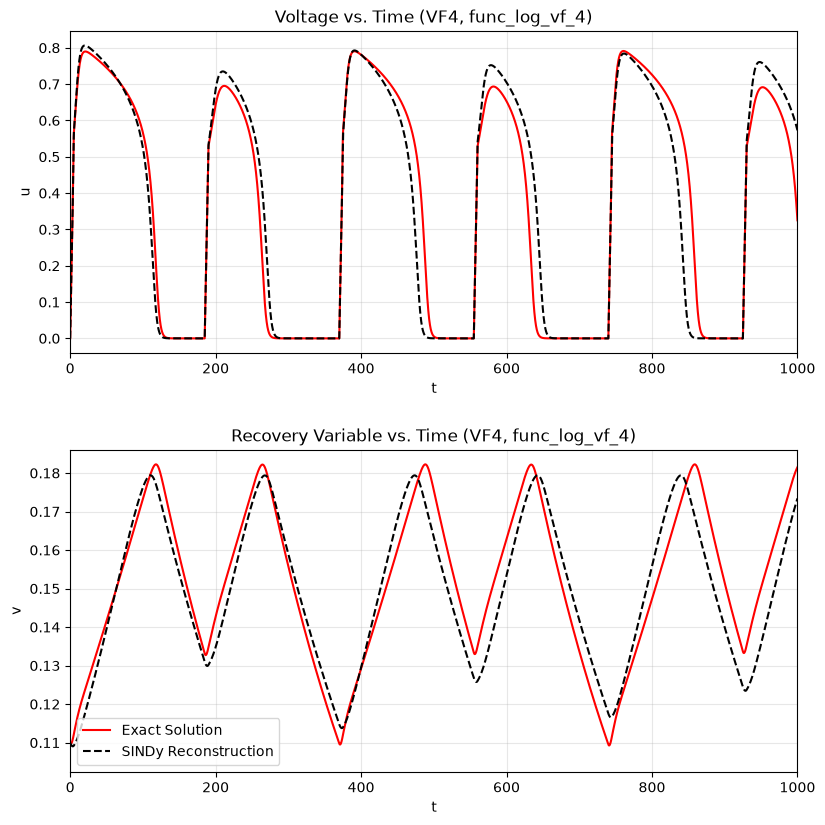

In [25]:
def func_log_vf_4(t):
    return logical_non_aut(t, period=185.0, dur=5.0, mag=0.12)
funcs_vf_4 = [func_log_vf_4]
c_models = []

# Test fit with same data and fitting non-autonomous terms.
for func in funcs_vf_4:
    print(f"----------Fitting with function: {func.__name__}----------")
    cur_gen_library_c = GenLibraryFit(func, func, fhn_variant="VF4", t_range=np.arange(0,4000,0.01), ics=x_0_vf_4, color="red")
    c_models.append(cur_gen_library_c.fit(end_time=1000))
    print('\n\n')

### d.) VF-FHN (b) Test
Test SINDy ID on the 7-parameter VF-FHN model (also called VF-7).

----------Fitting with function: func_log_vf_7----------
Number of SINDy terms for u', v': (7, 3)
Number of exact terms for u', v': (5, 3)
Mean Absolute Error of coefficients: 3.27913e-03

SINDy coefficients:
(u)' = -0.19901 u +  1.19753 u^2 +  0.00640 v^2 + -0.99852 u^3 + -0.04506 v^3 + -0.99981 u*v +  0.99758 f_td(t)
(v)' =  0.00705 u + -0.00500 u^2 + -0.00145 1
(t)' =  1.00000 1

Exact coefficients:
u' = -0.20000 u + 1.20000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00705 u + -0.00500 u^2 + -0.00146 1


Mean Absolute Error between reconstruction and true values: 1.39288e-03





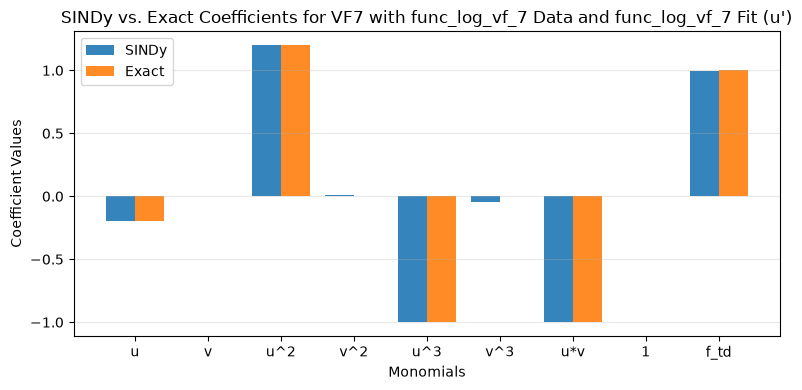

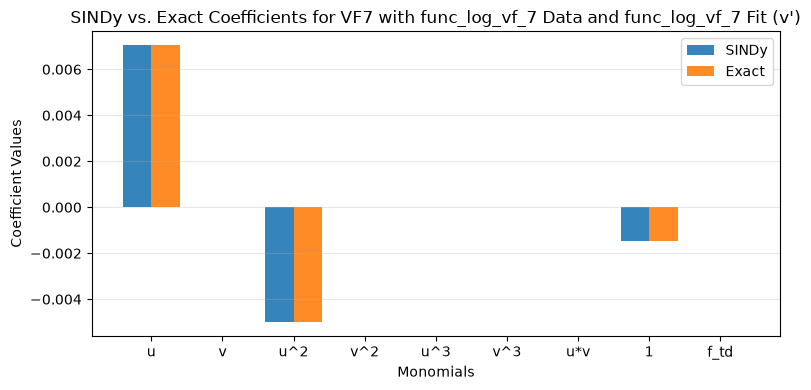

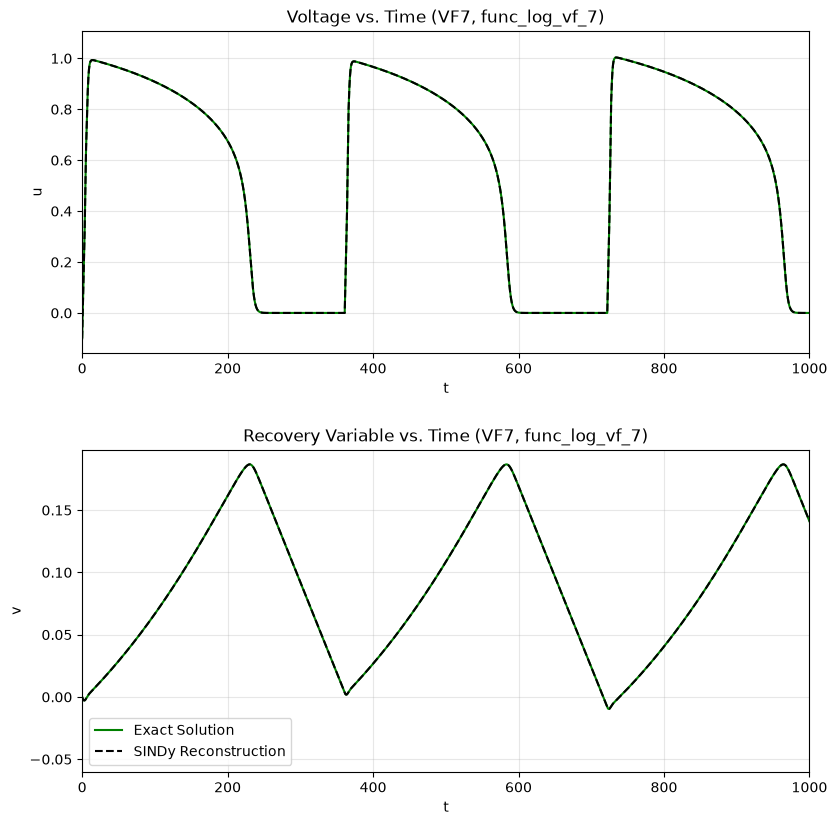

In [34]:
def func_log_vf_7(t):
    return logical_non_aut(t, period=361.0, dur=5.0, mag=0.12)
funcs_vf_7 = [func_log_vf_7]
d_models = []

# TODO VF-b has parameters slightly off based on t~1750
# Test fit with same data and fitting non-autonomous terms.
for func in funcs_vf_7:
    print(f"----------Fitting with function: {func.__name__}----------")
    cur_gen_library_d = GenLibraryFit(func, func, fhn_variant="VF7", color="green")
    d_models.append(cur_gen_library_d.fit(end_time=1000))
    print('\n\n')

Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 + f_{td}(t) \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

# 4.) Stimulus Amplitude Comparison

In [27]:
# (Uncomment to determine the optimal stimulus amplitude)

# Plot time-dependent FHN states for different stimulus amplitudes. The optimal amplitude will be around 1.5x to 2x the 
# first threshold amplitude that gives a good waveform (so ~1.5 * 0.08 = 0.12).
# for amp in np.arange(0.0,0.2,0.02):
#     states_fhn_td = odeint(fhn, cur_gen_library_a.x_0_fhn_td, cur_gen_library_a.t_fhn_td, args=(functools.partial(logical_non_aut, period=155.0, dur=5.0, mag=amp),), hmax=0.1) # Test --> lambda t: 0       Actual --> logical_non_aut
#     plt.plot(states_fhn_td[:,0:1], label='u')
#     plt.ylim(-0.5,1.5)
#     plt.xlim(0,50000)
#     plt.title(f"FHN Time-Dependent States with Stimulus Amplitude {amp:.2f}")
#     plt.show()

# 5.) Noisy Data Test
Add Gaussian noise to our data, then test the ability of SINDy to identify the equations under noisy conditions. Based on the results, it seems like ID usually works for noise levels with $\sigma < 0.001$.

----------Fitting with function: func_log_vf_4----------
Number of SINDy terms for u', v': (9, 4)
Number of exact terms for u', v': (5, 3)
Mean Absolute Error of coefficients: 4.40533e-01

SINDy coefficients:
(u)' = -0.19656 u + -0.31132 v +  1.18957 u^2 +  2.24001 v^2 + -0.99228 u^3 + -5.31044 v^3 + -0.99973 u*v +  0.01425 1 +  0.99595 f_td(t)
(v)' = -0.00027 u + -0.00373 v +  0.01549 u*v + -0.00012 1
(t)' =  1.00000 1

Exact coefficients:
u' = -0.20000 u + 1.20000 u^2 + -1.00000 u^3 + -1.00000 u*v + 1.00000 f_td
v' = 0.00550 u + -0.00500 v + -0.00500 u^2


Mean Absolute Error between reconstruction and true values: 8.54855e-02





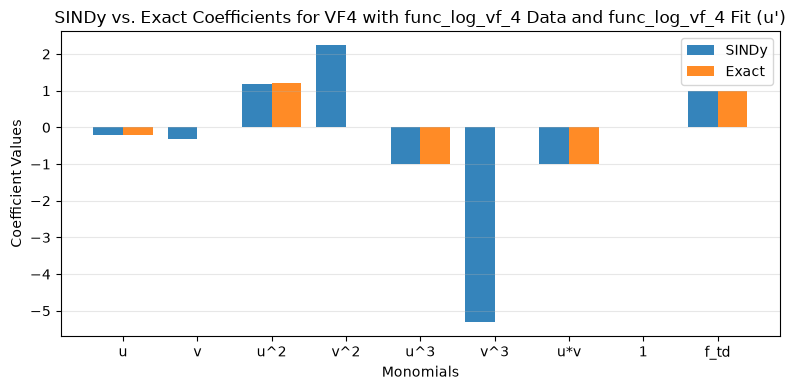

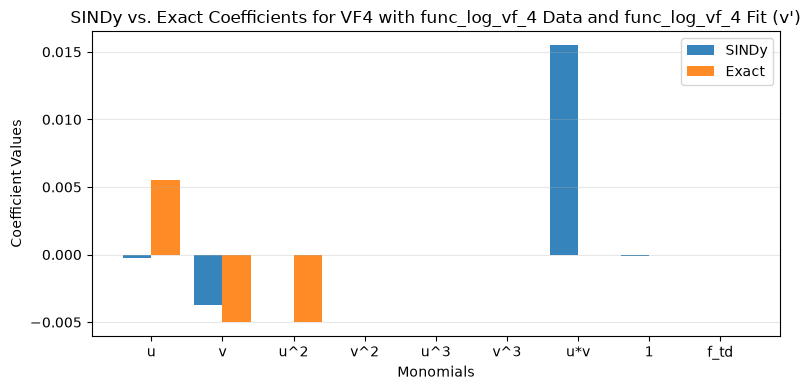

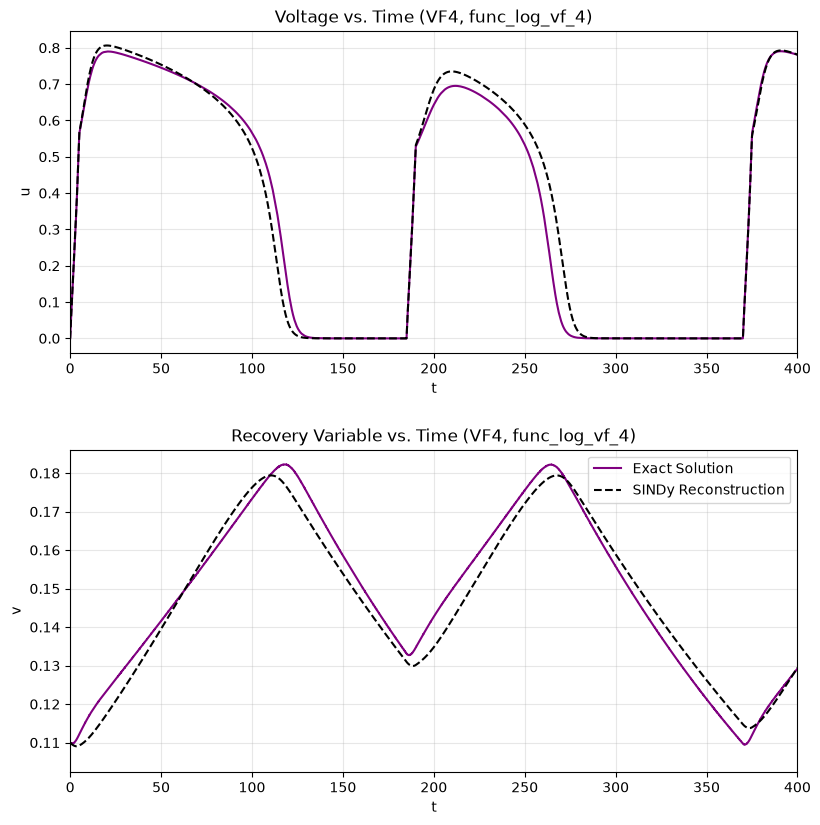

In [28]:
# Test fit with noise added. Since u is around 2x the magnitude of v on average (0.34 / 0.15 ~ 2.27), we add noise with std dev sigma
# to u and sigma/2 to v.
sigma = 1e-5

# Run the fit with VF4 stimulus.  Note that the reconstruction MAE is generally higher than the coefficient MAE for noisy data.
for func in funcs_vf_4:
    print(f"----------Fitting with function: {func.__name__}----------")
    cur_gen_library_c = GenLibraryFit(func, func, fhn_variant="VF4", t_range=np.arange(0,4000,0.01), ics=x_0_vf_4, color="purple", u_noise=sigma, v_noise=sigma/2)
    c_models.append(cur_gen_library_c.fit())
    print('\n\n')

# 6.) SINDy Identification Using Only Voltage
### a.) Takens' Theorem
In this section, we test how well SINDy can identify the equation $u'$ without the recovery equation $v'$. Instead, we pass a time-shifted version of the $u'$ equation for the remaining inputs, with the optimal delay interval determined by the average mutual information.  Takens' theorem states that at least $2n+1$ delayed copies in the embedded space will be needed to reconstruct the original dynamics of a system in $n$ dimensions.  In practice, we'll usually need a few more dimensions.

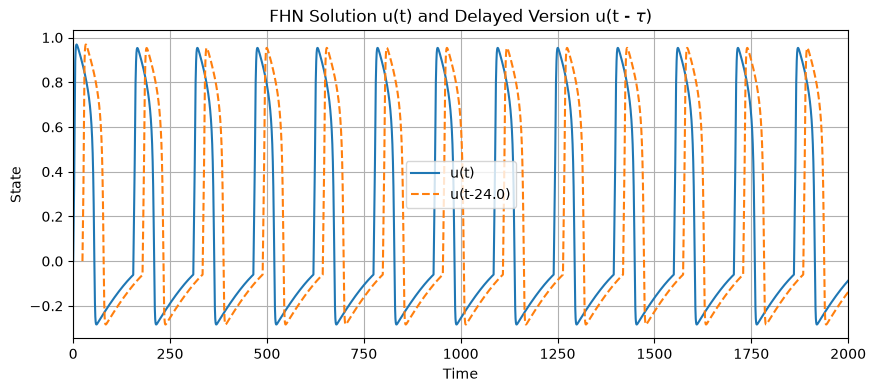

In [29]:
# Extract u from FHN solution
u_fhn = states_fhn[:, 0]

# Define time delay
# Notes on best practices for this:
# - In general, use tau around 1/4 of the AP duration (155 TU stimulus --> ~ 167 TU APD, so tau ~ 40).
# - According to Takens method results, tau ~ 24 appears better, so use that for sake of consistency in this comparison.
tau = 24.0

# Calculate number of steps to shift indices by and construct delayed u array using this value
shift_indices = int(tau / dt)
u_delayed = np.full_like(u_fhn, np.nan)
u_delayed[shift_indices:] = u_fhn[:-shift_indices]

# Compare u and shifted u
plt.figure(figsize=(10, 4))
plt.plot(t_fhn, u_fhn, label='u(t)')
plt.plot(t_fhn, u_delayed, label=f'u(t-{tau})', linestyle='--')
plt.xlabel('Time')
plt.ylabel('State')
plt.title(r'FHN Solution u(t) and Delayed Version u(t - $\tau$)')
plt.legend()
plt.grid(True)
plt.xlim(0, 2000)
plt.show()

(200000, 2)


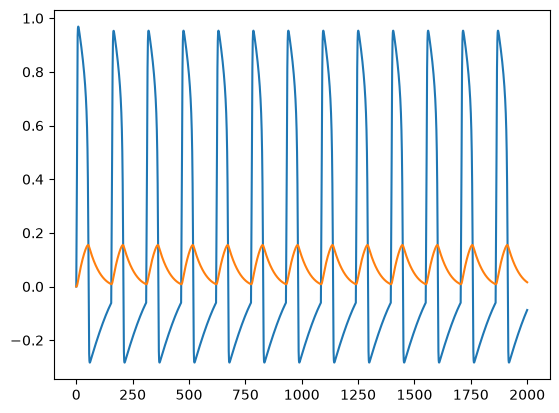

In [30]:
print(states_fhn.shape)
plt.plot(t_fhn, states_fhn)

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 2
(u(t-0))' =  2.085 u(t-0) + -53.650 u(t-0)^2 +  1.968 u(t-0)^3 + -2.209 u(t-24) + -52.658 u(t-24)^2 + -2.240 u(t-24)^3 +  106.677 u(t-0)*u(t-24) +  0.751 f_td(t)
(u(t-24))' =  5.214 u(t-0) +  12.136 u(t-0)^2 + -1.652 u(t-0)^3 + -5.121 u(t-24) +  9.900 u(t-24)^2 +  1.846 u(t-24)^3 + -22.306 u(t-0)*u(t-24) + -0.376 f_td(t)
(t)' =  1.000 1
['x0', 'x0^2', 'x0^3', 'x1', 'x1^2', 'x1^3', 'x0*x1', '1', 'f_td(x2)']
inputs_per_libary:  [[0], [0], [0], [1], [1], [1], [0, 1], [2]]
Takens reconstruction MAE (u): 3.38337e-01


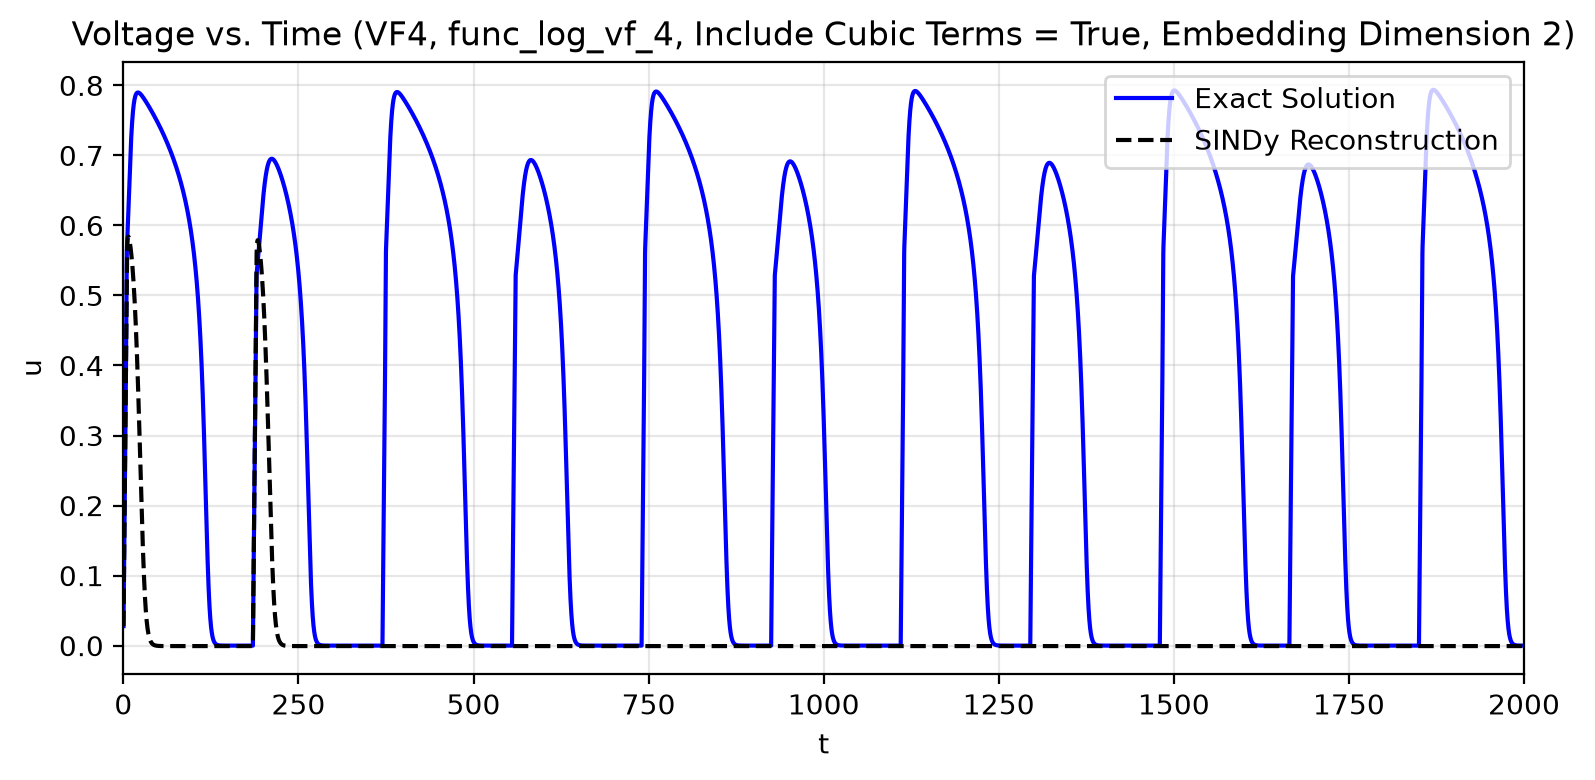

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 3
(u(t-0))' =  1.406 u(t-0) + -16.922 u(t-0)^2 +  5.037 u(t-0)^3 + -0.652 u(t-24) + -54.400 u(t-24)^2 + -8.477 u(t-24)^3 + -0.857 u(t-48) + -50.903 u(t-48)^2 +  3.215 u(t-48)^3 +  27.035 u(t-0)*u(t-24) +  95.496 u(t-24)*u(t-48) +  0.747 f_td(t)
(u(t-24))' =  2.695 u(t-0) +  19.027 u(t-0)^2 + -0.263 u(t-0)^3 + -0.592 u(t-24) +  18.754 u(t-24)^2 +  0.321 u(t-24)^3 + -2.077 u(t-48) + -38.215 u(t-0)*u(t-24) +  0.356 u(t-24)*u(t-48) + -0.205 f_td(t)
(u(t-48))' = -0.533 u(t-0) + -33.332 u(t-0)^2 +  3.453 u(t-0)^3 +  5.151 u(t-24) + -20.785 u(t-24)^2 + -7.368 u(t-24)^3 + -4.588 u(t-48) +  3.970 u(t-48)^3 +  61.121 u(t-0)*u(t-24) + -7.084 u(t-24)*u(t-48) +  0.088 f_td(t)
(t)' =  1.000 1
['x0', 'x0^2', 'x0^3', 'x1', 'x1^2', 'x1^3', 'x2', 'x2^2', 'x2^3', 'x0*x1', 'x1*x2', '1', 'f_td(x3)']
inputs_per_libary:  [[0], [0], [0

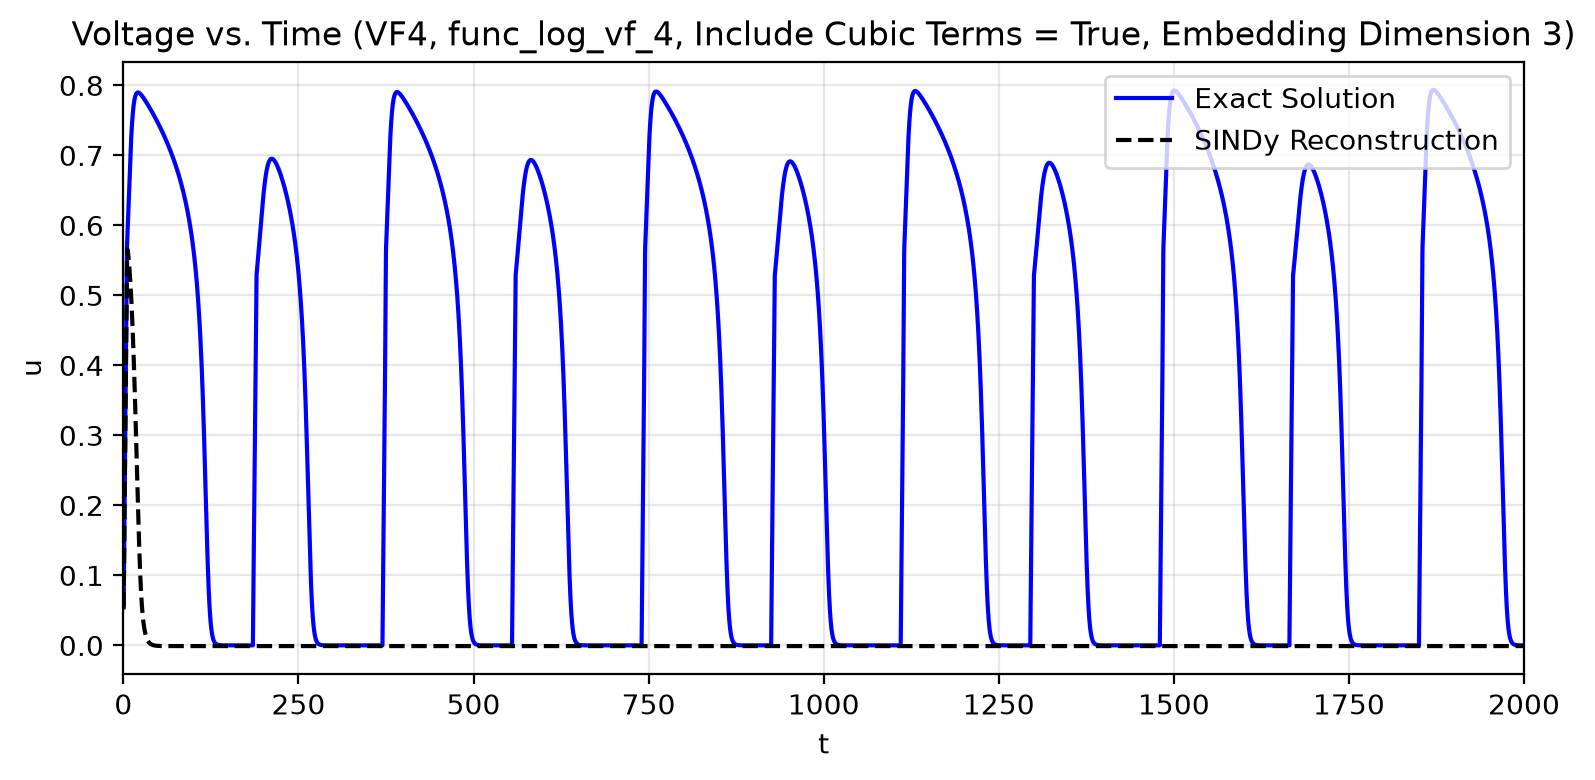

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 4
(u(t-0))' =  1.293 u(t-0) + -14.525 u(t-0)^2 +  1.433 u(t-0)^3 + -0.974 u(t-24) + -42.409 u(t-24)^2 +  3.745 u(t-24)^3 +  0.123 u(t-48) + -40.447 u(t-48)^2 + -10.503 u(t-48)^3 + -0.542 u(t-72) + -29.694 u(t-72)^2 +  5.109 u(t-72)^3 +  28.474 u(t-0)*u(t-24) +  48.643 u(t-24)*u(t-48) +  50.252 u(t-48)*u(t-72) +  0.760 f_td(t)
(u(t-24))' =  3.300 u(t-0) + -5.294 u(t-0)^2 +  1.888 u(t-0)^3 + -1.274 u(t-24) +  21.433 u(t-24)^2 + -7.463 u(t-24)^3 + -2.559 u(t-48) +  11.826 u(t-48)^2 +  8.825 u(t-48)^3 +  0.567 u(t-72) +  2.448 u(t-72)^2 + -3.177 u(t-72)^3 +  6.897 u(t-0)*u(t-24) + -37.409 u(t-24)*u(t-48) + -0.212 f_td(t)
(u(t-48))' = -1.024 u(t-0) +  4.511 u(t-0)^2 + -0.436 u(t-0)^3 +  4.274 u(t-24) + -13.992 u(t-24)^2 +  0.806 u(t-24)^3 + -1.547 u(t-48) + -3.241 u(t-48)^2 + -1.725 u(t-72) +  15.500 u(t-72)^2 + -0.4

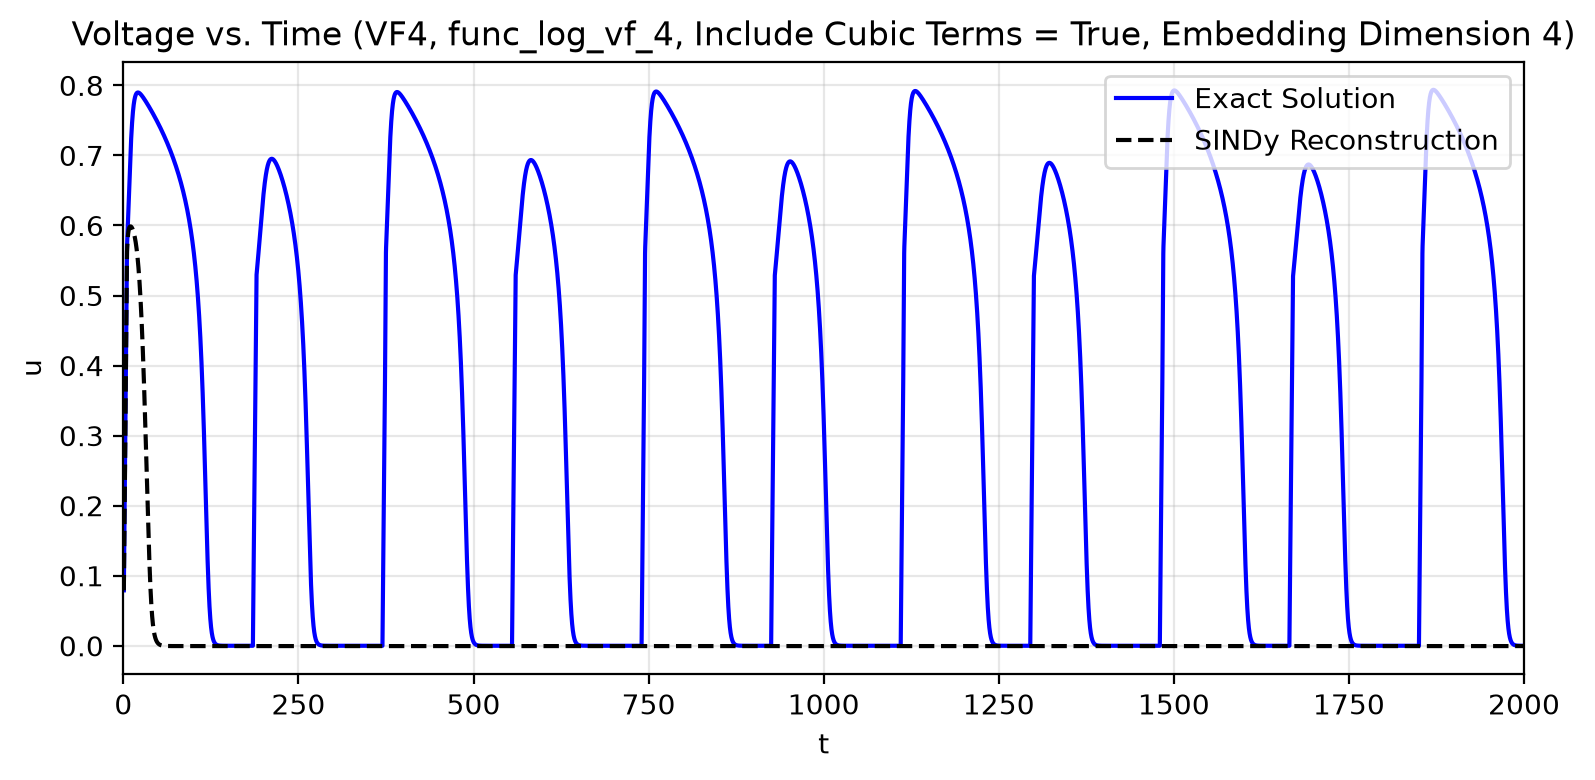

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 5
(u(t-0))' =  1.236 u(t-0) + -15.998 u(t-0)^2 +  0.426 u(t-0)^3 + -0.754 u(t-24) + -54.714 u(t-24)^2 +  4.540 u(t-24)^3 + -0.029 u(t-48) + -39.715 u(t-48)^2 + -3.698 u(t-48)^3 + -0.613 u(t-72) + -12.111 u(t-72)^2 + -6.952 u(t-72)^3 +  0.070 u(t-96) + -15.278 u(t-96)^2 +  5.488 u(t-96)^3 +  33.377 u(t-0)*u(t-24) +  67.262 u(t-24)*u(t-48) +  16.760 u(t-48)*u(t-72) +  20.684 u(t-72)*u(t-96) +  0.775 f_td(t)
(u(t-24))' =  3.344 u(t-0) + -6.084 u(t-0)^2 +  2.390 u(t-0)^3 + -1.338 u(t-24) +  26.172 u(t-24)^2 + -9.019 u(t-24)^3 + -2.976 u(t-48) +  19.469 u(t-48)^2 +  8.642 u(t-48)^3 +  1.356 u(t-72) + -0.092 u(t-72)^3 + -0.361 u(t-96) + -0.800 u(t-96)^2 + -1.867 u(t-96)^3 +  7.581 u(t-0)*u(t-24) + -45.223 u(t-24)*u(t-48) + -6.196 u(t-48)*u(t-72) +  5.004 u(t-72)*u(t-96) + -0.218 f_td(t)
(u(t-48))' = -25.382 u(t-0)^2 +

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\_core.py:646: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(rhs, x0, t, tfirst=True, **integrator_kws)


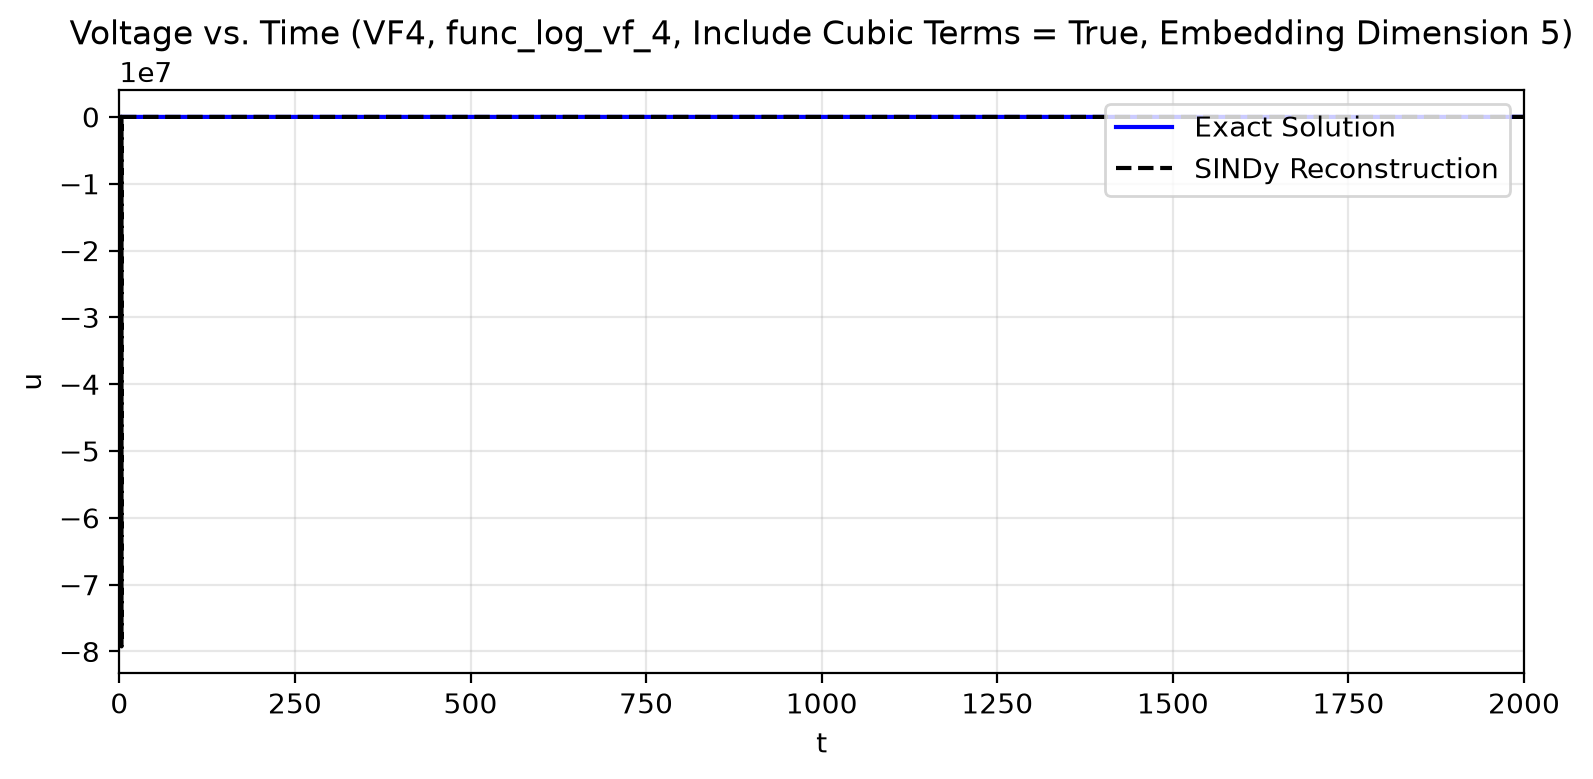

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 6
(u(t-0))' =  1.080 u(t-0) + -12.264 u(t-0)^2 + -1.241 u(t-0)^3 + -0.663 u(t-24) + -54.663 u(t-24)^2 +  7.617 u(t-24)^3 +  0.305 u(t-48) + -51.624 u(t-48)^2 + -5.650 u(t-48)^3 + -0.659 u(t-72) + -22.434 u(t-72)^2 + -0.400 u(t-96) +  3.176 u(t-96)^2 + -6.623 u(t-96)^3 +  0.253 u(t-120) + -8.201 u(t-120)^2 +  5.717 u(t-120)^3 +  28.743 u(t-0)*u(t-24) +  67.030 u(t-24)*u(t-48) +  44.233 u(t-48)*u(t-72) +  6.253 u(t-96)*u(t-120) +  0.788 f_td(t)
(u(t-24))' =  3.421 u(t-0) + -8.914 u(t-0)^2 +  2.985 u(t-0)^3 + -1.307 u(t-24) +  21.629 u(t-24)^2 + -9.776 u(t-24)^3 + -3.193 u(t-48) +  22.794 u(t-48)^2 +  8.550 u(t-48)^3 +  1.240 u(t-72) +  10.460 u(t-72)^2 + -1.800 u(t-72)^3 +  0.020 u(t-96) + -4.875 u(t-96)^2 +  1.905 u(t-96)^3 + -0.156 u(t-120) + -1.529 u(t-120)^2 + -1.809 u(t-120)^3 +  12.320 u(t-0)*u(t-24) + -39.8

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\_core.py:646: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(rhs, x0, t, tfirst=True, **integrator_kws)


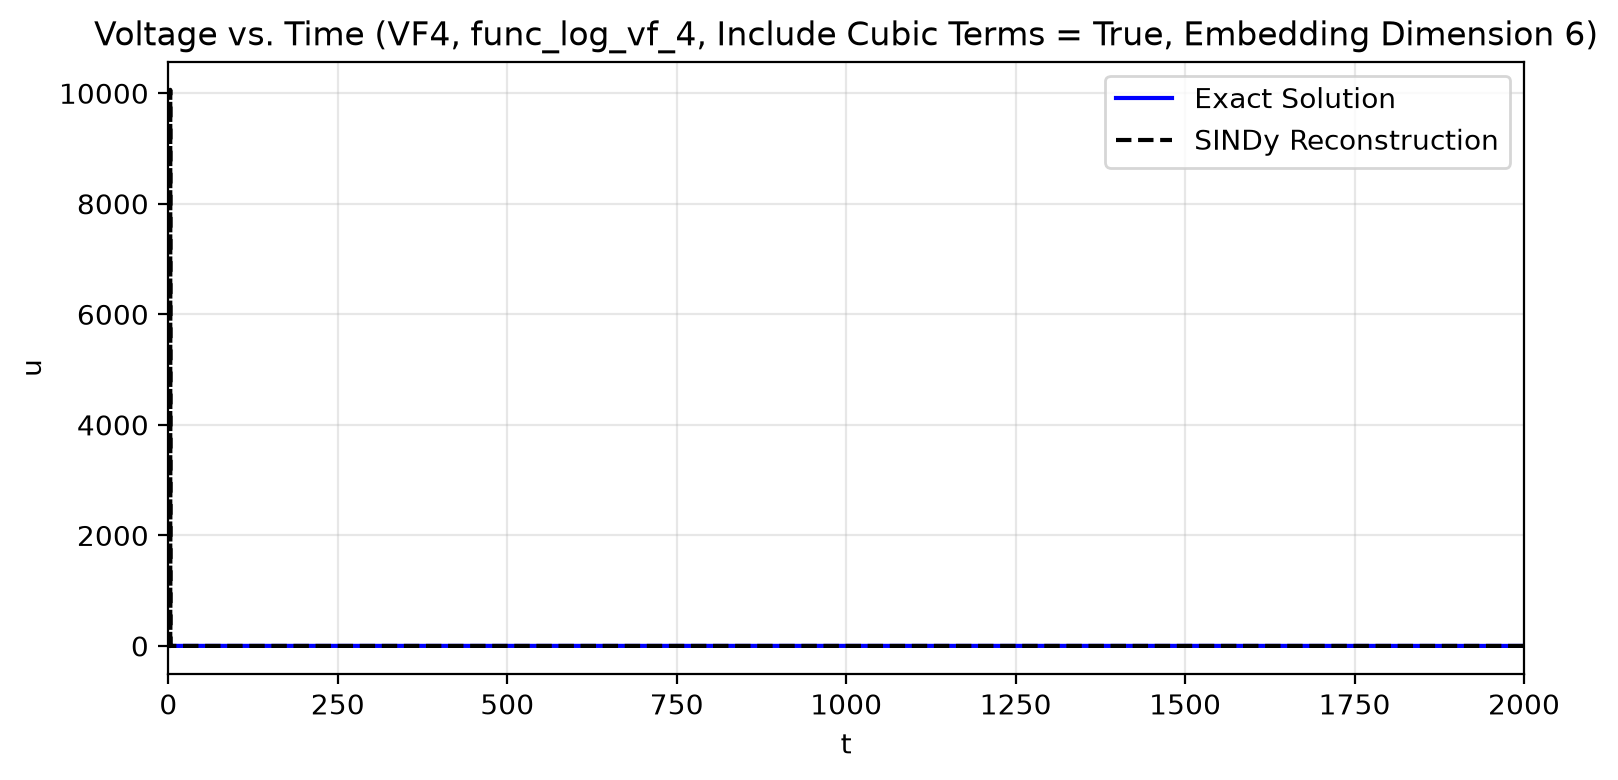

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 7
(u(t-0))' =  18.478 u(t-0)^2 + -4.309 u(t-0)^3 +  0.644 u(t-24) + -40.619 u(t-24)^2 +  11.641 u(t-24)^3 +  0.696 u(t-48) + -89.182 u(t-48)^2 + -2.871 u(t-48)^3 + -0.777 u(t-72) + -58.799 u(t-72)^2 + -3.674 u(t-72)^3 + -0.850 u(t-96) + -3.081 u(t-96)^3 + -0.270 u(t-120) +  20.131 u(t-120)^2 + -3.253 u(t-120)^3 +  0.468 u(t-144) + -2.125 u(t-144)^2 +  5.359 u(t-144)^3 + -27.972 u(t-0)*u(t-24) +  90.580 u(t-24)*u(t-48) +  90.453 u(t-48)*u(t-72) +  32.022 u(t-72)*u(t-96) + -27.279 u(t-96)*u(t-120) + -5.428 u(t-120)*u(t-144) +  0.826 f_td(t)
(u(t-24))' =  2.925 u(t-0) +  0.729 u(t-0)^2 +  3.875 u(t-0)^3 +  10.849 u(t-24)^2 + -11.036 u(t-24)^3 + -4.133 u(t-48) +  4.273 u(t-48)^2 +  9.756 u(t-48)^3 +  1.292 u(t-72) +  21.600 u(t-72)^2 + -4.405 u(t-72)^3 + -0.146 u(t-96) +  0.591 u(t-96)^2 +  2.627 u(t-96)^3 +  0.199 

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\_core.py:646: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(rhs, x0, t, tfirst=True, **integrator_kws)


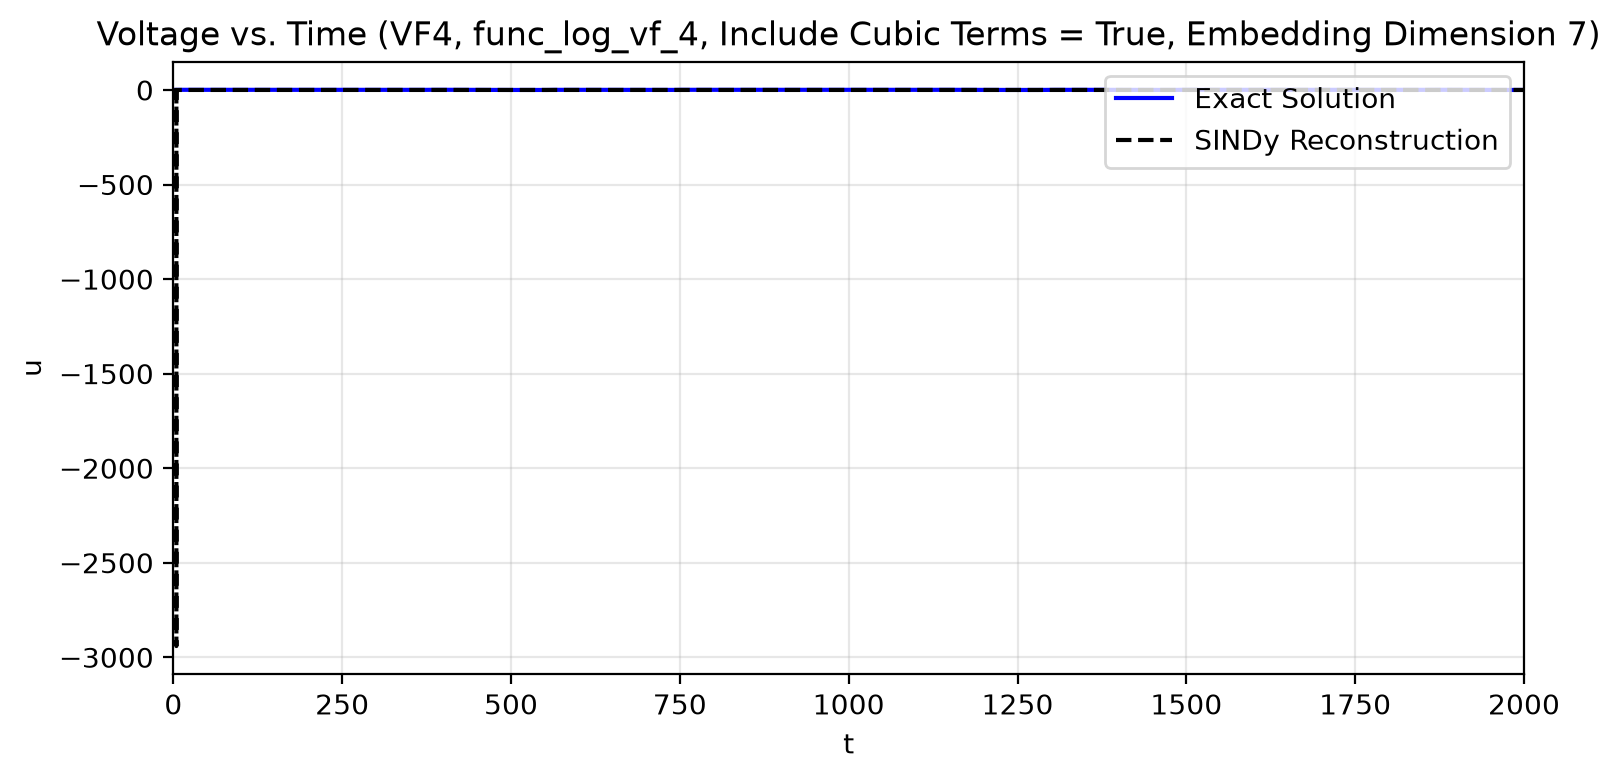

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 8
(u(t-0))' =  0.814 u(t-0) + -4.014 u(t-0)^2 + -3.506 u(t-0)^3 + -0.677 u(t-24) + -43.895 u(t-24)^2 +  9.439 u(t-24)^3 +  0.695 u(t-48) + -56.147 u(t-48)^2 + -2.660 u(t-48)^3 + -0.333 u(t-72) + -46.200 u(t-72)^2 + -2.910 u(t-72)^3 + -0.472 u(t-96) + -18.892 u(t-96)^2 + -0.296 u(t-120) +  11.441 u(t-120)^2 + -2.381 u(t-120)^3 + -0.013 u(t-144) +  8.798 u(t-144)^2 + -2.321 u(t-144)^3 +  0.205 u(t-168) + -7.166 u(t-168)^2 +  4.179 u(t-168)^3 +  15.841 u(t-0)*u(t-24) +  56.147 u(t-24)*u(t-48) +  59.258 u(t-48)*u(t-72) +  37.292 u(t-72)*u(t-96) + -18.971 u(t-120)*u(t-144) +  6.731 u(t-144)*u(t-168) +  0.805 f_td(t)
(u(t-24))' =  3.502 u(t-0) + -11.162 u(t-0)^2 +  3.711 u(t-0)^3 + -1.349 u(t-24) +  20.797 u(t-24)^2 + -10.905 u(t-24)^3 + -3.333 u(t-48) +  26.484 u(t-48)^2 +  9.037 u(t-48)^3 +  1.345 u(t-72) +  16.435 

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\_core.py:646: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(rhs, x0, t, tfirst=True, **integrator_kws)


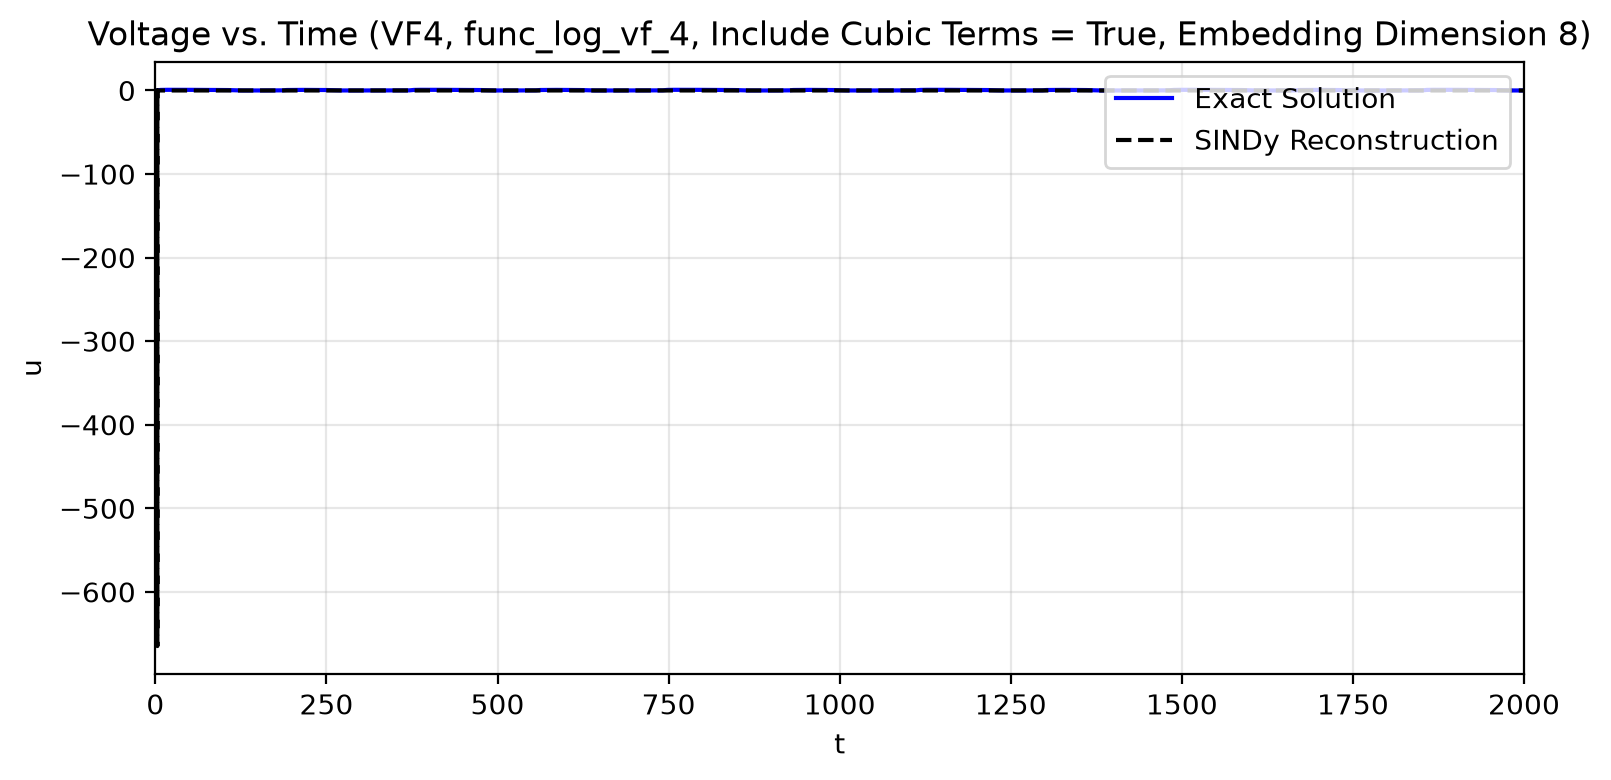

----------Fitting with function: func_log_vf_4----------

---------- SINDy with Takens Embedding ----------
Optimal time delay τ = 0.2400 (delay_idx = 24)
Embedding dimension = 9
(u(t-0))' =  0.840 u(t-0) + -6.242 u(t-0)^2 + -3.816 u(t-0)^3 + -0.655 u(t-24) + -48.145 u(t-24)^2 +  9.847 u(t-24)^3 +  0.516 u(t-48) + -52.074 u(t-48)^2 + -3.666 u(t-48)^3 + -0.472 u(t-72) + -34.265 u(t-72)^2 + -1.574 u(t-72)^3 + -0.231 u(t-96) + -10.964 u(t-96)^2 + -0.631 u(t-96)^3 + -0.051 u(t-120) + -1.828 u(t-120)^3 + -0.092 u(t-144) +  1.940 u(t-144)^2 +  1.474 u(t-144)^3 +  0.031 u(t-168) +  0.856 u(t-168)^2 + -3.776 u(t-168)^3 +  0.040 u(t-192) + -9.897 u(t-192)^2 +  3.816 u(t-192)^3 +  20.880 u(t-0)*u(t-24) +  58.857 u(t-24)*u(t-48) +  49.979 u(t-48)*u(t-72) +  20.632 u(t-72)*u(t-96) +  2.109 u(t-96)*u(t-120) +  0.988 u(t-120)*u(t-144) + -7.385 u(t-144)*u(t-168) +  12.945 u(t-168)*u(t-192) +  0.809 f_td(t)
(u(t-24))' =  3.473 u(t-0) +  2.820 u(t-0)^2 + -0.840 u(t-0)^3 + -2.720 u(t-24) +  50.726 u(t-2

c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\_core.py:646: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return odeint(rhs, x0, t, tfirst=True, **integrator_kws)


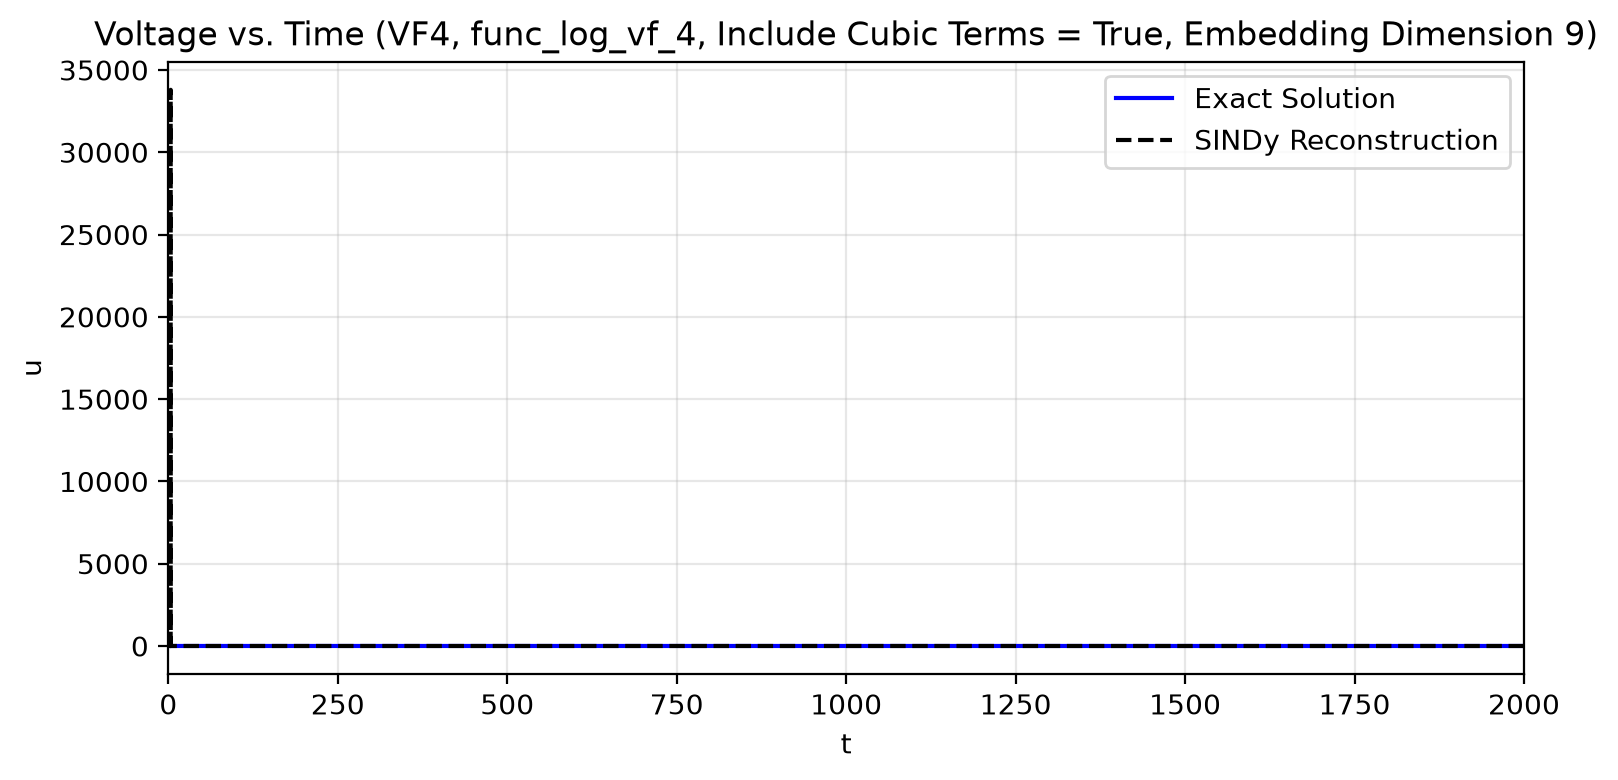

In [44]:
takens_td_models = []
n_embed_range = range(2,10)

# Test fit with fit_takens() method, which uses delay embeddings to reconstruct the dynamics, specifying the number of embedding
# dimensions with n_embed.
for i in n_embed_range:
    print(f"----------Fitting with function: {func_log_vf_4.__name__}----------")
    cur_gen_library_tk = GenLibraryFit(
                func_log_vf_4,
                func_log_vf_4,
                fhn_variant="VF4",
                t_range=np.arange(0, 2000, 0.01),
                ics=x_0_vf_4,
                color="blue"
            )
    cur_gen_library_tk.fit_takens(is_cubic=True, n_embed=i)
    cur_gen_library_tk.reconstruct_and_plot_takens(end_time=2000)
    
    takens_td_models.append(cur_gen_library_tk)

### b.) Latent ODE Fit
Transform the system of 2 ODEs described by the VF-FHN variants to a single 2nd-order ODE in order to remove the need to fit the latent variable $v$.

----------Fitting with function: func_log----------
Differentiation method parameters:  {'save_smooth': True, 'smoother': <function savgol_filter at 0x000001AC9AB4C460>, 'smoother_kws': {'window_length': 5, 'polyorder': 3, 'axis': 0}}
Number of SINDy terms for u', v': (6, 8)
Number of exact terms for u', v': (1, 7)
Mean Absolute Error of coefficients: 1.01300e-01

SINDy coefficients:
(u)' = -0.00002 u +  0.00002 u^2 +  0.99993 u_dot + -0.00041 u*u_dot +  0.00064 u^2*u_dot +  0.00027 f_td(t)
(u_dot)' = -0.03270 u + -0.00615 u^2 +  0.04716 u^3 + -0.14744 u_dot +  1.46132 u*u_dot + -2.68642 u^2*u_dot + -0.00345 1 +  0.43521 f_td(t)
(t)' =  1.00000 1

Exact coefficients:
u' = 1.00000 u_dot
v' = -0.00600 u + 0.01100 u^2 + -0.01000 u^3 + -0.11000 u_dot + 2.20000 u*u_dot + -3.00000 u^2*u_dot + 0.01000 f_td


Mean Absolute Error between reconstruction and true values: 1.91533e-01





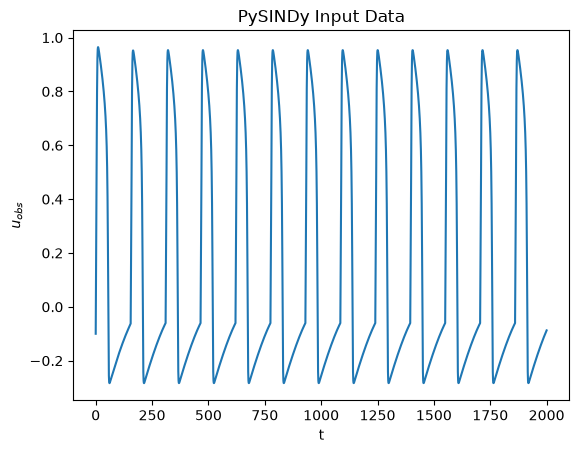

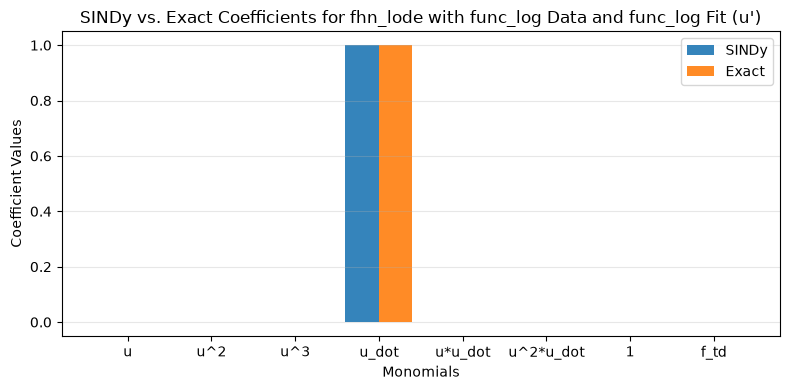

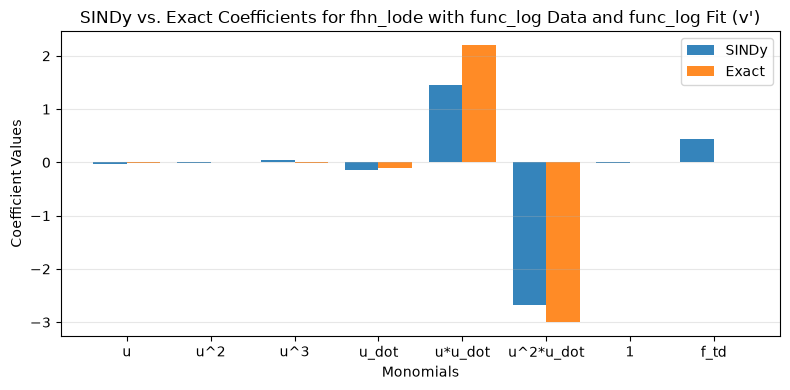

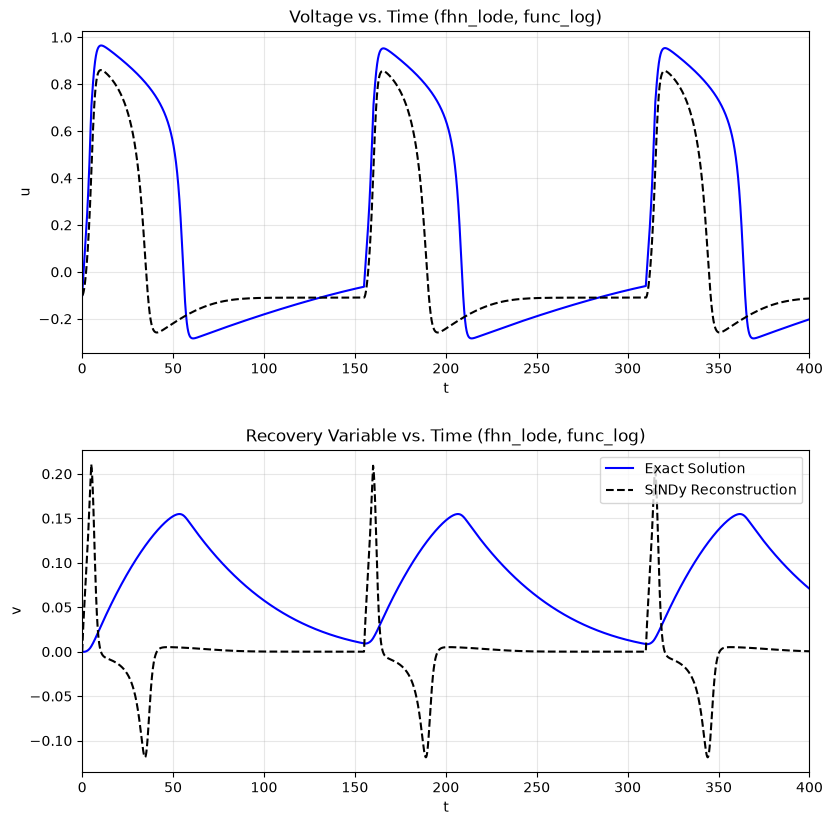

In [ ]:
latent_ODE_models = []

# TODO Modify math to convert L-ODE formulation for "cardiac" + "VF4" + "VF7" variants
# Test fit with same data and fitting non-autonomous terms.
print(f"----------Fitting with function: {func_log.__name__}----------")
cur_gen_library_lode = GenLibraryFit(func_log, func_log, fhn_variant="fhn_lode", ics=np.array([-0.1,0]), t_range=np.arange(0,2000,0.01), color="blue")
latent_ODE_models.append(cur_gen_library_lode.fit_latent_ODE(is_weak=False))
print('\n\n')

----------Fitting with function: func_log----------
Differentiation method parameters:  {'save_smooth': True, 'smoother': <function savgol_filter at 0x000001AC9AB4C460>, 'smoother_kws': {'window_length': 5, 'polyorder': 3, 'axis': 0}}


c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


Number of SINDy terms for u', v': (1, 0)
Number of exact terms for u', v': (1, 6)
Mean Absolute Error of coefficients: 3.81214e-01

SINDy coefficients:
(u)' =  1.00000 u_dot
(u_dot)' =  0.00000
(t)' =  1.00000 1

Exact coefficients:
u' = 1.00000 u_dot
v' = -0.00600 u + 0.01100 u^2 + -0.01000 u^3 + -0.11000 u_dot + 2.20000 u*u_dot + -3.00000 u^2*u_dot


Mean Absolute Error between reconstruction and true values: 9.99443e-02





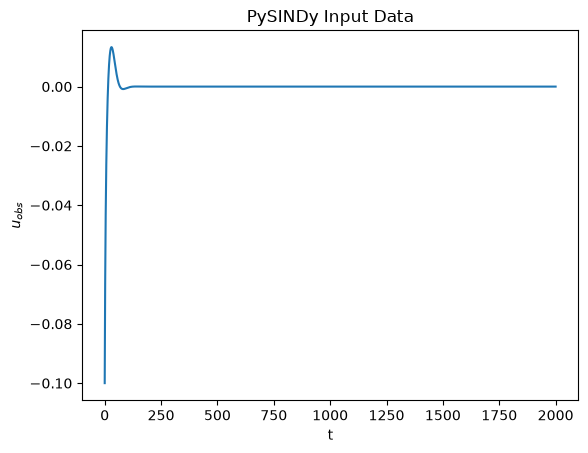

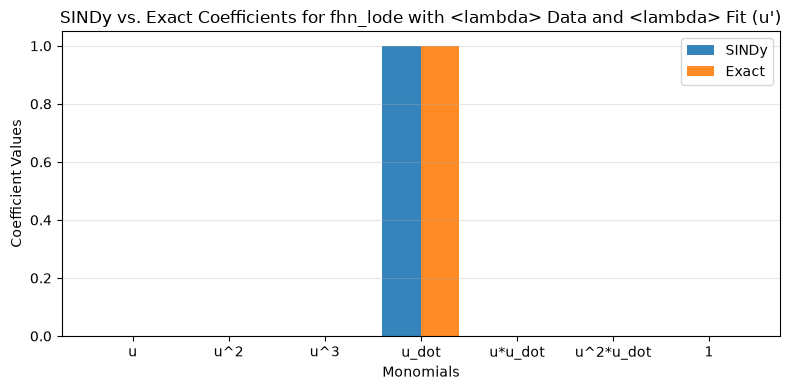

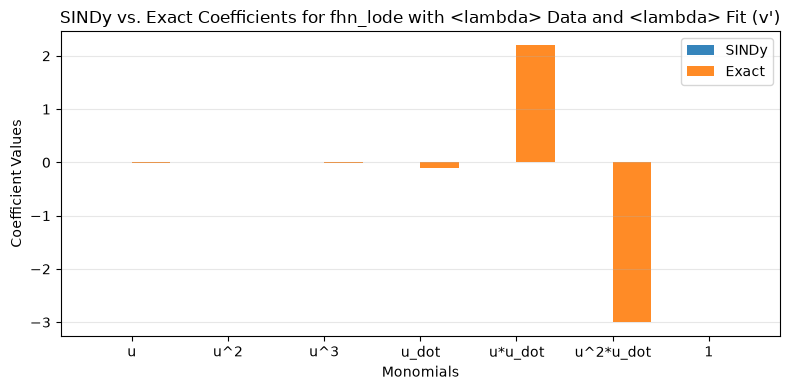

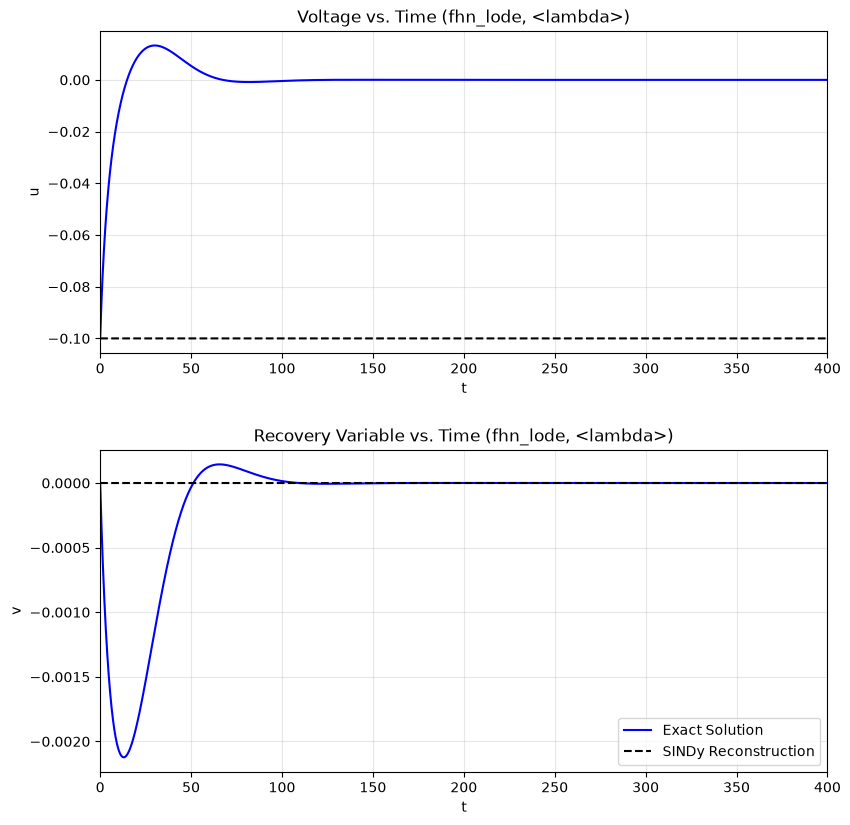

In [ ]:
latent_ODE_models_no_osc = []

# TODO Uninteresting behavior where system decays to 0 and stops there; need to find better parameters for this test.
# L-ODE fit w/out non-autonomous term to eliminate potential impact of I'(t)
print(f"----------Fitting with function: {func_log.__name__}----------")
cur_gen_library_lode_no_osc = GenLibraryFit(lambda t: 0, lambda t: 0, fhn_variant="fhn_lode", ics=np.array([-0.1,0]), t_range=np.arange(0,2000,0.01), color="blue")
latent_ODE_models_no_osc.append(cur_gen_library_lode_no_osc.fit_latent_ODE(is_weak=False))
print('\n\n')

### c.) Weak Form of Latent ODE Fit
Since a lot of noise is introduced by taking 2nd-order derivatives, let's apply Weak SINDy to the L-ODE method above and compare the results.

----------Fitting with function: func_log----------
Differentiation method parameters:  {'save_smooth': True, 'smoother': <function savgol_filter at 0x000001AC9AB4C460>, 'smoother_kws': {'window_length': 5, 'polyorder': 3, 'axis': 0}}
Number of SINDy terms for u', v': (1, 2)
Number of exact terms for u', v': (1, 7)
Mean Absolute Error of coefficients: 3.34099e-01

SINDy coefficients:
(u)' =  1.00000 u_dot
(u_dot)' = -0.00165 u +  0.00023 1
(t)' =  1.00000 1

Exact coefficients:
u' = 1.00000 u_dot
v' = -0.00600 u + 0.01100 u^2 + -0.01000 u^3 + -0.11000 u_dot + 2.20000 u*u_dot + -3.00000 u^2*u_dot + 0.01000 f_td


c:\Users\Cole\OneDrive\Documents\_Repos\SINDy-for-Cardiac-Electrophysiology\pysindy_new\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


IndexError: index 135593 is out of bounds for axis 0 with size 1

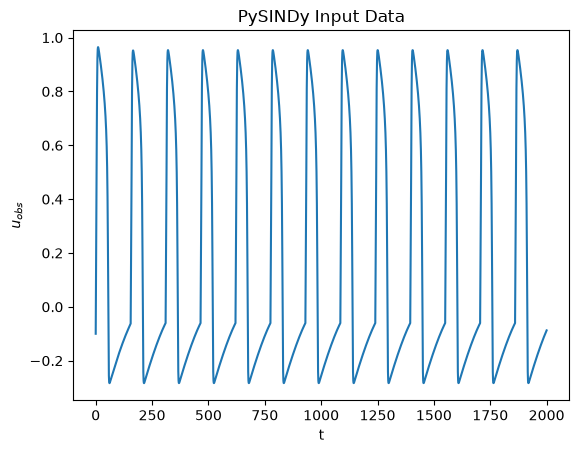

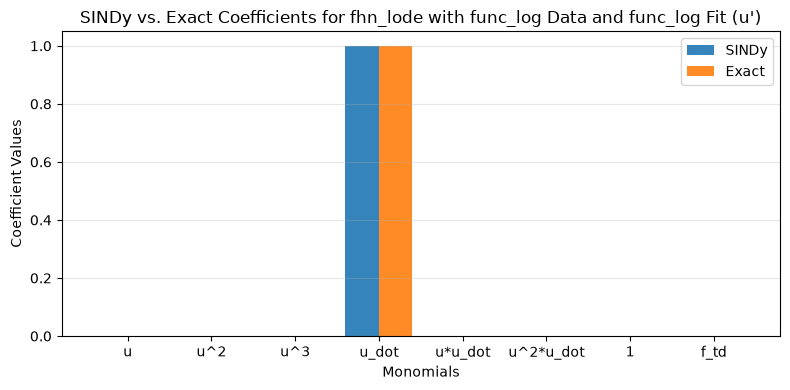

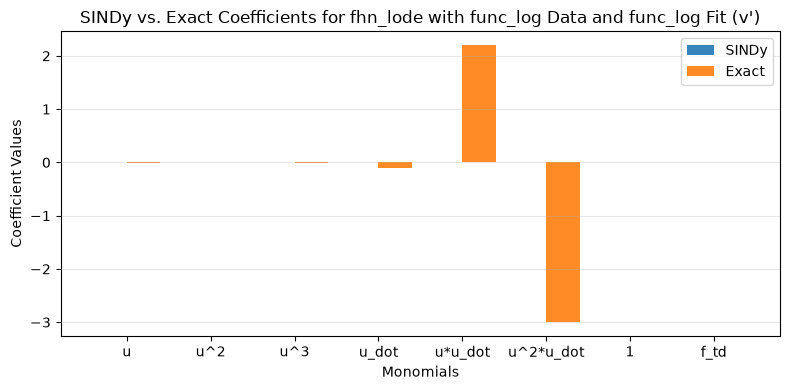

In [ ]:
latent_ODE_models_weak = []

# Test fit with same data and fitting non-autonomous terms.
# dt = 0.01
print(f"----------Fitting with function: {func_log.__name__}----------")
cur_gen_library_lode = GenLibraryFit(func_log, func_log, fhn_variant="fhn_lode", ics=np.array([-0.1,0]), t_range=np.arange(0,2000,0.01), color="blue")
latent_ODE_models_weak.append(cur_gen_library_lode.fit_latent_ODE(is_weak=True))
print('\n\n')

# TODO Incorporate comparison from L-ODE paper—can't generally use direct coefficient comparison, so try SMAPE instead.

# TODO Loop over ICs, dts, smoothing k to get best fit

In [ ]:
# dt = 0.0001
# latent_ODE_models_weak = []

# print(f"----------Fitting with function: {func_log.__name__}----------")
# cur_gen_library_lode = GenLibraryFit(func_log, func_log, fhn_variant="fhn_lode", ics=np.array([-0.1,0]), t_range=np.arange(0,2000,0.0001), color="blue")
# latent_ODE_models_weak.append(cur_gen_library_lode.fit_latent_ODE(is_weak=True))
# print('\n\n')

----------Fitting with function: func_log----------
Differentiation method parameters:  {'save_smooth': True, 'smoother': <function savgol_filter at 0x000001E96A77C3B0>, 'smoother_kws': {'window_length': 5, 'polyorder': 3, 'axis': 0}}
Number of SINDy terms for u', v': (1, 2)
Number of exact terms for u', v': (1, 7)
Mean Absolute Error of coefficients: 5.27052e-02

SINDy coefficients:
(u)' =  1.00000 u_dot
(u_dot)' =  1.94011 u*u_dot + -3.43639 u^2*u_dot
(t)' =  1.00000 1

Exact coefficients:
u' = 1.00000 u_dot
v' = -0.00600 u + 0.01100 u^2 + -0.01000 u^3 + -0.11000 u_dot + 2.20000 u*u_dot + -3.00000 u^2*u_dot + 0.01000 f_td





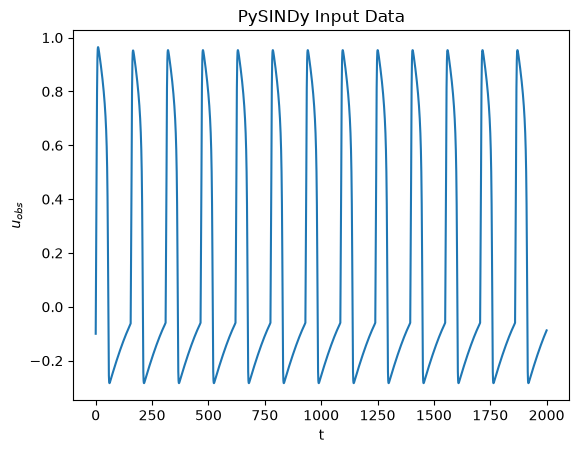

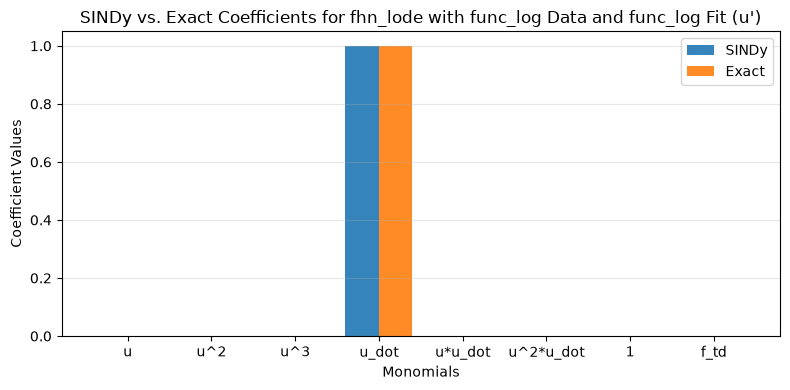

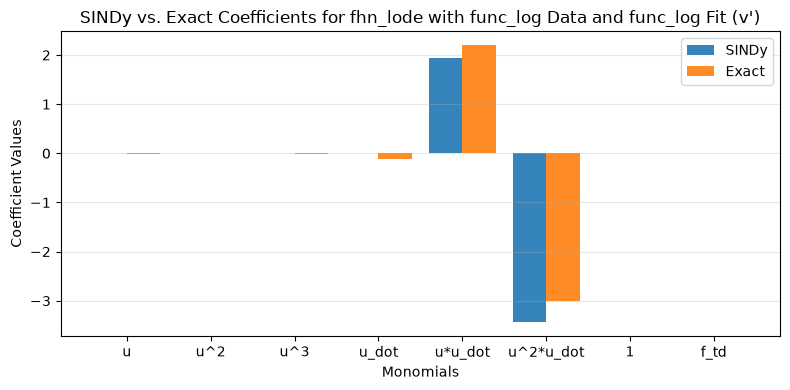

In [ ]:
# dt = 0.0001 (normal)
latent_ODE_models_weak = []

print(f"----------Fitting with function: {func_log.__name__}----------")
cur_gen_library_lode = GenLibraryFit(func_log, func_log, fhn_variant="fhn_lode", ics=np.array([-0.1,0]), t_range=np.arange(0,2000,0.0001), color="blue")
latent_ODE_models_weak.append(cur_gen_library_lode.fit_latent_ODE(is_weak=False))
print('\n\n')